## Imports and setup

In [1]:
# Import required libraries
import os
import time
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

import networkx as nx
from scipy.stats import pearsonr
from functools import partial
from pathlib import Path
from scipy.spatial.distance import pdist
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.random_projection import johnson_lindenstrauss_min_dim, GaussianRandomProjection

import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device detection and setup
def get_device():
    """Detect and return the best available device for PyTorch."""
    if torch.cuda.is_available():
        device = torch.device('cuda')
        print(f"Using CUDA device: {torch.cuda.get_device_name(0)}")
        print(f"CUDA version: {torch.version.cuda}")
        print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        device = torch.device('mps')
        print("Using MPS (Metal Performance Shaders) device")
    else:
        device = torch.device('cpu')
        print("Using CPU device")
    
    print(f"PyTorch version: {torch.__version__}")
    return device

# Set device
device = get_device()

Using MPS (Metal Performance Shaders) device
PyTorch version: 2.8.0


# ============================================================================
# Phase 1: TRANSCRIPTOMICS as Embeddings
# ============================================================================

In [2]:
# Configuration
CONFIG_TRANSCRIPTOMICS = {
    'embedding_dim': 128,  # D - configurable embedding dimension (will be updated based on JL lemma)
    'hidden_dim': 512,      # Hidden dimension for Q/K projections
    'batch_size': 16,       # Batch size for training
    'learning_rate': 1e-3,  # Learning rate
    'num_samples': 9600,     # Total number of augmented samples (different random projections)
    'use_attention_scores': False, # Use attention scores instead of weights
    'attn_dropout': 0.0,  # Dropout for attention mask beyond diagonal (self) masking
    'consistency_weight': 0.0,  # Weight for batch consistency regularization
    'consistency_type': 'variance',  # 'variance' (default) or 'frobenius'
    'jl_epsilon': 0.25,     # JL lemma epsilon when using random_projection dataset
    'n_layers': 1,           # Number of decoder blocks (1 = shallow, >1 = deep)
    'mlp_expansion': 2,      # MLP hidden layer expansion factor
    'dropout': 0.1,          # Dropout rate for MLP layers
}

print("Phase 1 Configuration (Transcriptomics):")
for key, value in CONFIG_TRANSCRIPTOMICS.items():
    print(f"  {key}: {value}")
print(f"\nDevice: {device}")

Phase 1 Configuration (Transcriptomics):
  embedding_dim: 128
  hidden_dim: 512
  batch_size: 16
  learning_rate: 0.001
  num_samples: 9600
  use_attention_scores: False
  attn_dropout: 0.0
  consistency_weight: 0.0
  consistency_type: variance
  jl_epsilon: 0.25
  n_layers: 1
  mlp_expansion: 2
  dropout: 0.1

Device: mps


## Data Preparation and Embedding Generation

We start by loading the single-cell transcriptome data. This dataset contains gene expression data for 22,469 genes across 130 neuron classes, providing much more granular resolution than bulk-sorted data.

Our approach:
1. Load and preprocess the transcriptome data
2. Apply log1p transformation and standardization
3. Optionally, performe PCA to reduce dimensionality and visualization
4. Generate initial (N, D) embedding matrix where N=130 neuron classes


In [3]:
# Load GSE136049 neuron-class transcriptome (preferring log-normalized means)
transcriptomics_data_dir = 'data/transcriptomics/Single Cell Seq/GEO (GSE 136049)'
lognorms_path = f'{transcriptomics_data_dir}/GSE136049_genes_by_neurons_lognorm_means.csv'
counts_path    = f'{transcriptomics_data_dir}/GSE136049_genes_by_neurons_counts.csv'
preferred_path = lognorms_path

if os.path.exists(preferred_path):
    df = pd.read_csv(preferred_path, index_col=0)
    used = preferred_path
    X_ = df.T.values  # neurons x genes
else:
    assert os.path.exists(counts_path), "Missing GSE136049 CSVs; run load_data.ipynb first."
    df = pd.read_csv(counts_path, index_col=0)
    used = counts_path
    # counts → log1p before standardization
    X_ = np.log1p(df.T.values)

# NOTE: We are using the term "labels" to just mean the name (i.e. string) that is assigned to the neuron. 
# In the transcritomic data those labels are a mixture of neuron class and class members.
neuron_labels = df.columns.tolist()
transcript_names = df.index.tolist()
print(f"Loaded: {used}")
print(f"Original table shape (genes x neuron_labels): {df.shape}")
print(f"Transposed to (neurons x genes): {X_.shape}")
print(f"Neuron names (first 10): {neuron_labels[:10]}")
print(f"Feature names (first 10): {transcript_names[:10]}")

X_original = X_
print(f"X_original shape: {X_original.shape}")
# NOTE: Do NOT standardize features (genes) with StandardScaler. It strips away the variance information.
print(f"Without standardization {X_original.mean(axis=0).shape} genes (first 5) \n\tmean: {X_original.mean(axis=0)[:5]}, \n\tstd: {X_original.std(axis=0)[:5]}")

N_neurons = len(neuron_labels)
assert N_neurons == X_original.shape[0]
print(f"Number of neurons: {N_neurons}")
print(f"Neuron names: {neuron_labels}")


Loaded: data/transcriptomics/Single Cell Seq/GEO (GSE 136049)/GSE136049_genes_by_neurons_lognorm_means.csv
Original table shape (genes x neuron_labels): (22469, 130)
Transposed to (neurons x genes): (130, 22469)
Neuron names (first 10): ['ADA', 'ADE', 'ADF', 'ADL', 'AFD', 'AIA', 'AIB', 'AIM', 'AIN', 'AIY']
Feature names (first 10): ['WBGene00010957', 'WBGene00010958', 'WBGene00014454', 'WBGene00010959', 'WBGene00010960', 'WBGene00010961', 'WBGene00000829', 'WBGene00010962', 'WBGene00010963', 'WBGene00010964']
X_original shape: (130, 22469)
Without standardization (22469,) genes (first 5) 
	mean: [2.87590796 1.01728045 0.8490579  1.07566784 1.96477043], 
	std: [0.92014032 0.41039817 0.42220107 0.57693753 0.81696442]
Number of neurons: 130
Neuron names: ['ADA', 'ADE', 'ADF', 'ADL', 'AFD', 'AIA', 'AIB', 'AIM', 'AIN', 'AIY', 'AIZ', 'ALA', 'ALM', 'ALN', 'AQR', 'AS', 'ASEL', 'ASER', 'ASG', 'ASH', 'ASI', 'ASJ', 'ASK', 'AUA', 'AVA', 'AVB', 'AVD', 'AVE', 'AVF', 'AVG', 'AVH', 'AVJ', 'AVK', 'AVL'

#### **OPTIONAL:** Choose a random subset of `input_dim` features to keep as the original data `X_original` to get embedded by the dataset class.


In [4]:
# Select a subset of features from X_original for embedding. 
# This gives us a manageable but still high-dimensional input space.

input_dim = X_original.shape[1] # Choosing all features is just shuffling the features
print(f"X_original shape: {X_original.shape}")
print(f"Selecting {input_dim} random features from {X_original.shape[1]} total features")

# Randomly select input_dim features without replacement
selected_features = np.random.choice(X_original.shape[1], size=input_dim, replace=False)
print(f"Selected features: {selected_features}")

# Create new X_original with only selected features
X_original = X_original[:, selected_features]
print(f"\nNew X_original shape: {X_original.shape}")
# NOTE: Do NOT standardize features (genes) with StandardScaler. It strips away the variance information.
print(f"Without standardization {X_original.mean(axis=0).shape} genes (first 5) \n\tmean: {X_original.mean(axis=0)[:5]}, \n\tstd: {X_original.std(axis=0)[:5]}")

print(f"\nData ready for embedding: {X_original.shape}")

X_original shape: (130, 22469)
Selecting 22469 random features from 22469 total features
Selected features: [ 4704 15071 14981 ...  5390   860 15795]

New X_original shape: (130, 22469)
Without standardization (22469,) genes (first 5) 
	mean: [0.11445684 0.00069365 0.00016286 0.01129373 0.00013161], 
	std: [0.06226655 0.00428849 0.00184978 0.01740574 0.00105634]

Data ready for embedding: (130, 22469)


#### By morphological criteria, the 302 neurons of the worm are classified into 118 distinct types, and from the database of reporter transgene expression patterns, most of these are postulated to have unique molecular signatures.

File used was obtained from the [supplemental information](https://www.sciencedirect.com/science/article/pii/S096098221631212X?via%3Dihub#app2) of this paper:
   >  Hobert, O., Glenwinkel, L. & White, J. Revisiting Neuronal Cell Type Classification in Caenorhabditis elegans. Curr. Biol. 26, R1197–R1203 (2016).


In [5]:
# Load neuron metadata from supplementary data file
neuron_metadata_df = pd.read_excel('data/1-s2.0-S096098221631212X-mmc2.xlsx', 
                                    sheet_name='List_with_genes.txt',
                                    header=3,    # Headers are on row 4 (0-based index 3)
                                    nrows=302,   # Data is in rows 5-306 (302 rows total)
                                    usecols=[0,1,2,3]  # Only first 4 columns
                                 ).ffill() # Forward fill empty cells to handle merged-cell-like data

print(f"Loaded neuron metadata: {neuron_metadata_df.shape}")
print(f"Columns: {neuron_metadata_df.columns.tolist()}")
print(f"Sample rows:")
print(neuron_metadata_df.head())

# Create lookup dictionaries mapping both neuron labels and classes to neurotransmitter
label_to_neurotransmitter = dict(zip(neuron_metadata_df['Class member'], 
                                    neuron_metadata_df['Neurotransmitter identity']))
class_to_neurotransmitter = dict(zip(neuron_metadata_df['Neuron class'].unique(),
                                    neuron_metadata_df.groupby('Neuron class')['Neurotransmitter identity'].first()))

# Create lookup dictionary mapping labels to their neuron class
label_to_class = dict(zip(neuron_metadata_df['Class member'],
                         neuron_metadata_df['Neuron class']))

# No type information in this dataset, so we'll remove those dictionaries
print(f"\nLookup dictionaries created:")
print(f"  label_to_neurotransmitter: {len(label_to_neurotransmitter)} entries")
print(f"  class_to_neurotransmitter: {len(class_to_neurotransmitter)} entries") 
print(f"  label_to_class: {len(label_to_class)} entries")


Loaded neuron metadata: (302, 4)
Columns: ['Neuron class', 'Class member', 'Lineage', 'Neurotransmitter identity']
Sample rows:
  Neuron class Class member        Lineage Neurotransmitter identity
0          ADA         ADAL  AB.plapaaaapp                       Glu
1          ADA         ADAR  AB.prapaaaapp                       Glu
2          ADE         ADEL  AB.plapaaaapa                        DA
3          ADE         ADER  AB.prapaaaapa                        DA
4          ADF         ADFL   AB.alpppppaa                       Ach

Lookup dictionaries created:
  label_to_neurotransmitter: 302 entries
  class_to_neurotransmitter: 118 entries
  label_to_class: 302 entries


In [6]:
# Map each neuron name in neuron_labels to its neurotransmitter and class
neuron_neurotransmitters = []
neuron_classes = []

for neuron in neuron_labels:
    # Have to do some cleaning up of the names first
    neuron = neuron.split('_')[0].replace('0', '') # This won't handle VA10 correctly, but it's good enough for now
    
    # First try exact match in label dictionary
    if neuron in label_to_neurotransmitter:
        nt = label_to_neurotransmitter[neuron]
        cls = label_to_class[neuron]
    # Then try match in class dictionary
    elif neuron in class_to_neurotransmitter:
        nt = class_to_neurotransmitter[neuron]
        cls = neuron  # The neuron label is already a class name
    else:
        # Mark as unknown if not found
        nt = '<Missing>'
        cls = '<Missing>'
    
    neuron_neurotransmitters.append(nt)
    neuron_classes.append(cls)

# Convert to arrays
neuron_neurotransmitters = np.array(neuron_neurotransmitters)
neuron_classes = np.array(neuron_classes)

print(f"\nNeuron metadata mapping:")
print(f"Total neurons: {len(neuron_labels)}")
print(f"Unique neurotransmitters: {np.unique(neuron_neurotransmitters)}")
print(f"Unique classes: {np.unique(neuron_classes)}")
print(f"Unknown neurotransmitters: {(neuron_neurotransmitters == '<Missing>').sum()}")
print(f"Unknown classes: {(neuron_classes == '<Missing>').sum()}")

# Show some examples of the mapping
print(f"\nSample mappings:")
for i in range(min(10, len(neuron_labels))):
    print(f"  {neuron_labels[i]} -> NT: {neuron_neurotransmitters[i]}, Class: {neuron_classes[i]}")



Neuron metadata mapping:
Total neurons: 130
Unique neurotransmitters: ['5HT' 'ACh' 'ACh (minor)' 'Ach' 'DA' 'GABA' 'Glu' 'Glu & 5HT'
 'Octopamine' 'Unknown (orphan)' 'unknown MA (cat-1)']
Unique classes: ['ADA' 'ADE' 'ADF' 'ADL' 'AFD' 'AIA' 'AIB' 'AIM' 'AIN' 'AIY' 'AIZ' 'ALA'
 'ALM' 'ALN' 'AQR' 'AS' 'ASE' 'ASG' 'ASH' 'ASI' 'ASJ' 'ASK' 'AUA' 'AVA'
 'AVB' 'AVD' 'AVE' 'AVF' 'AVG' 'AVH' 'AVJ' 'AVK' 'AVL' 'AVM' 'AWA' 'AWB'
 'AWC' 'BAG' 'BDU' 'CAN' 'CEP' 'DA' 'DB' 'DVA' 'DVB' 'DVC' 'FLP' 'HSN'
 'I1' 'I2' 'I3' 'I4' 'I5' 'I6' 'IL1' 'IL2' 'LUA' 'M1' 'M2' 'M3' 'M4' 'M5'
 'MC' 'MI' 'NSM' 'OLL' 'OLQ' 'PDA' 'PDB' 'PDE' 'PHA' 'PHB' 'PHC' 'PLM'
 'PLN' 'PQR' 'PVC' 'PVD' 'PVM' 'PVN' 'PVP' 'PVQ' 'PVR' 'PVT' 'PVW' 'RIA'
 'RIB' 'RIC' 'RID' 'RIF' 'RIG' 'RIH' 'RIM' 'RIP' 'RIR' 'RIS' 'RIV' 'RMD'
 'RME' 'RMF' 'RMG' 'RMH' 'SAA' 'SAB' 'SDQ' 'SIA' 'SIB' 'SMB' 'SMD' 'URA'
 'URB' 'URX' 'URY' 'VA' 'VB' 'VC' 'VD']
Unknown neurotransmitters: 0
Unknown classes: 0

Sample mappings:
  ADA -> NT: Glu, Class: ADA
  ADE -

### Principal Component Analysis (PCA) on the original data

This allows us to visualize if th data always show distinctive groupings (e.g. by neurotransmitter or class) in low dimensions.

Applying PCA preprocessing to reduce dimensions and visualize data...
Original data shape: (130, 22469)
Using 129 PCA components (max allowable: 129)
PCA preprocessed data shape: (130, 129)
Explained variance ratio (first 10 components): [0.1010845  0.0711716  0.04499718 0.04002918 0.03708121 0.03003903
 0.02515988 0.02317245 0.02031772 0.01915597]
Total explained variance: 1.0000


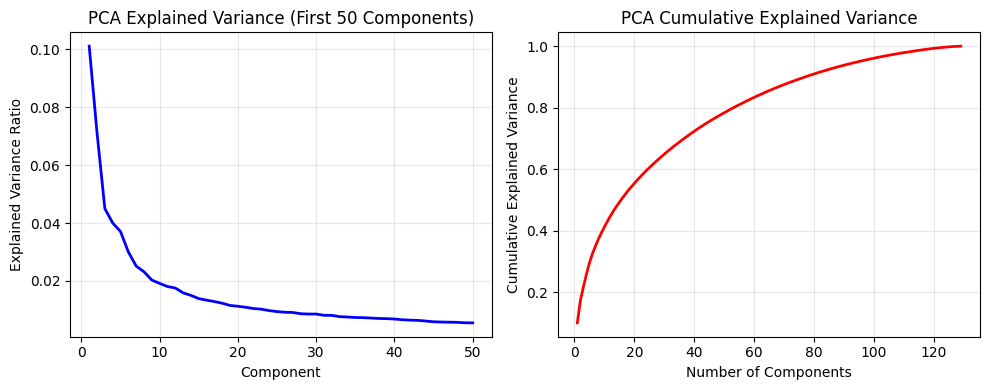

Plotting first two PCA components with metadata coloring...


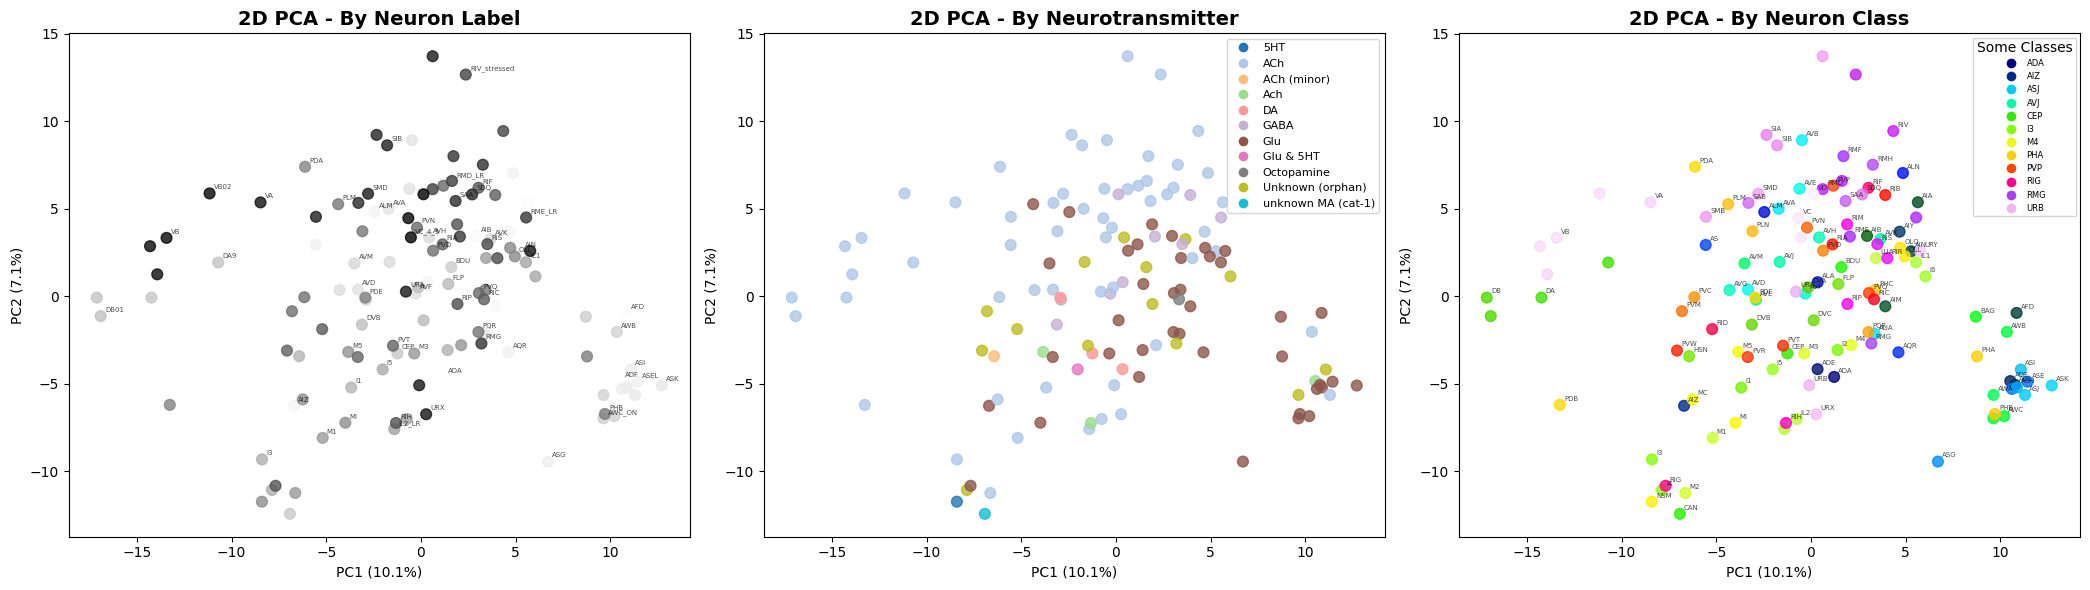

PCA visualization complete
X_pca shape: (130, 129)
Number of neurons: 130
Number of principal components: 129

Applying MDS to visualize data in 2D...
MDS transformed data shape: (130, 2)


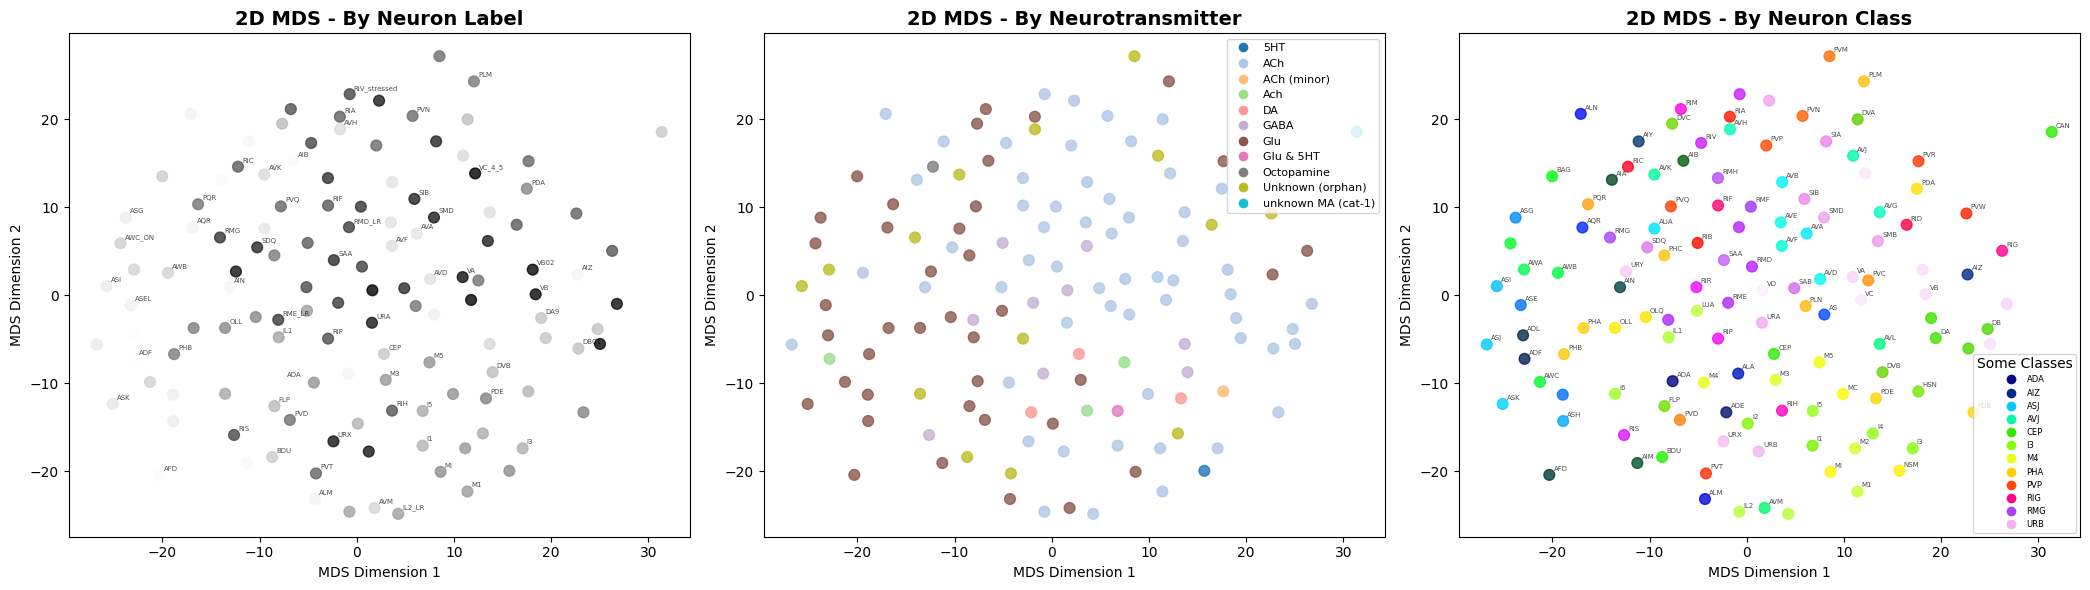

MDS visualization complete
X_mds shape: (130, 2)
Number of neurons: 130


In [7]:
# PCA Preprocessing for Dimensionality Reduction and Visualization
print("Applying PCA preprocessing to reduce dimensions and visualize data...")
print(f"Original data shape: {X_original.shape}")

# Maximum allowable PCA components is min(n_samples-1, n_features)
max_pca_components = min(N_neurons - 1, X_original.shape[1])
n_pca_components = max_pca_components  # Use maximum to preserve as much variance as possible

print(f"Using {n_pca_components} PCA components (max allowable: {max_pca_components})")

# Fit PCA
pca_preprocess = PCA(n_components=n_pca_components, random_state=41)
X_pca = pca_preprocess.fit_transform(X_original)

print(f"PCA preprocessed data shape: {X_pca.shape}")
print(f"Explained variance ratio (first 10 components): {pca_preprocess.explained_variance_ratio_[:10]}")
print(f"Total explained variance: {pca_preprocess.explained_variance_ratio_.sum():.4f}")

# Plot cumulative explained variance
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, min(50, len(pca_preprocess.explained_variance_ratio_)) + 1), 
         pca_preprocess.explained_variance_ratio_[:50], 'b-', linewidth=2)
plt.xlabel('Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Explained Variance (First 50 Components)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(pca_preprocess.explained_variance_ratio_) + 1), 
         np.cumsum(pca_preprocess.explained_variance_ratio_), 'r-', linewidth=2)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Cumulative Explained Variance')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot first two PCA components for visualization with metadata coloring
print("Plotting first two PCA components with metadata coloring...")

# Create figure with 3 subplots: original coloring, neurotransmitter, cell type
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# Prepare metadata color mappings
unique_nt = np.sort(np.unique(neuron_neurotransmitters))
nt_to_color = {nt: i/len(unique_nt) for i, nt in enumerate(unique_nt)}
unique_cls = np.sort(np.unique(neuron_classes))
cls_to_color = {cls: i/len(unique_cls) for i, cls in enumerate(unique_cls)}

# Use grayscale colormap for neuron labels and viridis for classes
label_cmap = plt.cm.Greys
nt_cmap = plt.cm.tab20  # Keep tab20 for neurotransmitters since there are few unique values
cls_cmap = plt.cm.gist_ncar  # Can handle many distinct values

# Plot 1: Original (by neuron index) with annotations for every other neuron
ax = axes[0]
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], 
                    c=range(len(neuron_labels)), cmap=label_cmap, s=60, alpha=0.8)
ax.set_title('2D PCA - By Neuron Label', fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca_preprocess.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca_preprocess.explained_variance_ratio_[1]:.1%})')

# Add text annotations for every other neuron
for i in range(0, len(neuron_labels), 2):
    ax.annotate(neuron_labels[i],
                (X_pca[i, 0], X_pca[i, 1]),
                xytext=(3, 3), textcoords='offset points',
                fontsize=5, alpha=0.7)

# Plot 2: Colored by neurotransmitter
ax = axes[1]
colors = [nt_cmap(nt_to_color[nt]) for nt in neuron_neurotransmitters]
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, s=60, alpha=0.8)
ax.set_title('2D PCA - By Neurotransmitter', fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca_preprocess.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca_preprocess.explained_variance_ratio_[1]:.1%})')

# Add legend for neurotransmitters
handles = [plt.Line2D([0], [0], marker='o', color='w', 
                     markerfacecolor=nt_cmap(nt_to_color[nt]), 
                     markersize=8, label=nt) for nt in unique_nt]
ax.legend(handles=handles, loc='best', fontsize=8)

# Plot 3: Colored by neuron class with text annotations
ax = axes[2]
colors = [cls_cmap(cls_to_color[cls]) for cls in neuron_classes]
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, s=60, alpha=0.8)
ax.set_title('2D PCA - By Neuron Class', fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca_preprocess.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca_preprocess.explained_variance_ratio_[1]:.1%})')

# Add legend for subset of classes (every kth class)
k = len(unique_cls) // 12 + 1  # Show ~12 classes
selected_classes = unique_cls[::k]
handles = [plt.Line2D([0], [0], marker='o', color='w',
                     markerfacecolor=cls_cmap(cls_to_color[cls]),
                     markersize=8, label=cls) for cls in selected_classes]
ax.legend(handles=handles, loc='best', fontsize=6, title='Some Classes')

# For each unique class, find one representative point and add text annotation
for cls in unique_cls:
    # Find indices where this class appears
    cls_indices = np.where(neuron_classes == cls)[0]
    if len(cls_indices) > 0:
        # Take the first occurrence as representative
        idx = cls_indices[0]
        # Add text annotation with small offset
        ax.annotate(cls, 
                   (X_pca[idx, 0], X_pca[idx, 1]),
                   xytext=(3, 3), textcoords='offset points',
                   fontsize=5, alpha=0.7)

plt.tight_layout()
plt.show()

print("PCA visualization complete")
print(f"X_pca shape: {X_pca.shape}")
print(f"Number of neurons: {N_neurons}")
print(f"Number of principal components: {X_pca.shape[1]}")

# -----------------------------------------------------------
# MDS Visualization for Dimensionality Reduction (similar to above)
print("\nApplying MDS to visualize data in 2D...")
distance_matrix = euclidean_distances(X_original)

mds = MDS(n_components=2, dissimilarity='precomputed', random_state=41)
X_mds = mds.fit_transform(distance_matrix)
print(f"MDS transformed data shape: {X_mds.shape}")

# Create figure with 3 subplots: original coloring, neurotransmitter, cell type
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# Plot 1: Original (by neuron index) with annotations for every other neuron
ax = axes[0]
scatter = ax.scatter(X_mds[:, 0], X_mds[:, 1], 
                    c=range(len(neuron_labels)), cmap=label_cmap, s=60, alpha=0.8)
ax.set_title('2D MDS - By Neuron Label', fontsize=14, fontweight='bold')
ax.set_xlabel('MDS Dimension 1')
ax.set_ylabel('MDS Dimension 2')

# Add text annotations for every other neuron
for i in range(0, len(neuron_labels), 2):
    ax.annotate(neuron_labels[i],
                (X_mds[i, 0], X_mds[i, 1]),
                xytext=(3, 3), textcoords='offset points',
                fontsize=5, alpha=0.7)

# Plot 2: Colored by neurotransmitter
ax = axes[1]
colors = [nt_cmap(nt_to_color[nt]) for nt in neuron_neurotransmitters]
scatter = ax.scatter(X_mds[:, 0], X_mds[:, 1], c=colors, s=60, alpha=0.8)
ax.set_title('2D MDS - By Neurotransmitter', fontsize=14, fontweight='bold')
ax.set_xlabel('MDS Dimension 1')
ax.set_ylabel('MDS Dimension 2')

# Add legend for neurotransmitters
handles = [plt.Line2D([0], [0], marker='o', color='w', 
                      markerfacecolor=nt_cmap(nt_to_color[nt]), 
                      markersize=8, label=nt) for nt in unique_nt]
ax.legend(handles=handles, loc='best', fontsize=8)

# Plot 3: Colored by neuron class with text annotations
ax = axes[2]
colors = [cls_cmap(cls_to_color[cls]) for cls in neuron_classes]
scatter = ax.scatter(X_mds[:, 0], X_mds[:, 1], c=colors, s=60, alpha=0.8)
ax.set_title('2D MDS - By Neuron Class', fontsize=14, fontweight='bold')
ax.set_xlabel('MDS Dimension 1')
ax.set_ylabel('MDS Dimension 2')

# Add legend for subset of classes (every kth class)
k = len(unique_cls) // 12 + 1  # Show ~12 classes
selected_classes = unique_cls[::k]
handles = [plt.Line2D([0], [0], marker='o', color='w',
                     markerfacecolor=cls_cmap(cls_to_color[cls]),
                     markersize=8, label=cls) for cls in selected_classes]
ax.legend(handles=handles, loc='best', fontsize=6, title='Some Classes')

# For each unique class, find one representative point and add text annotation
for cls in unique_cls:
    # Find indices where this class appears
    cls_indices = np.where(neuron_classes == cls)[0]
    if len(cls_indices) > 0:
        idx = cls_indices[0]
        ax.annotate(cls, 
                   (X_mds[idx, 0], X_mds[idx, 1]),
                   xytext=(3, 3), textcoords='offset points',
                   fontsize=5, alpha=0.7)

plt.tight_layout()
plt.show()

print("MDS visualization complete")
print(f"X_mds shape: {X_mds.shape}")
print(f"Number of neurons: {N_neurons}")



## Custom Transcriptome Dataset with Johnson-Lindenstrauss Random Projection

Since we have only one (N, D) embedding matrix from the original transcriptome data, we need to generate multiple training samples. Our innovation is to create synthetic but meaningful variations using Johnson-Lindenstrauss random Gaussian projections.

**Key insight**: Each random projection preserves pairwise distances between neurons with high probability (JL lemma guarantee), while creating novel projections. This allows generation of effectively unlimited training samples with theoretically grounded distance preservation.


In [8]:
# Calculate minimum dimension needed for JL lemma
n_samples = N_neurons  # We're preserving distances between neurons
epsilon = CONFIG_TRANSCRIPTOMICS['jl_epsilon']
min_dim = johnson_lindenstrauss_min_dim(n_samples=n_samples, eps=epsilon)
print(f"JL minimum dimension for n={n_samples}, eps={epsilon}: {min_dim}")
print(f"Original dimension: {X_original.shape[1]}")

# Create and fit GaussianRandomProjection
grp = GaussianRandomProjection(n_components=min_dim.item(), eps=epsilon)
X_projected = grp.fit_transform(X_original)

print(f"\nGaussian Random Projection output shape: {X_projected.shape}")
print(f"Projection matrix shape: {grp.components_.shape}")

JL minimum dimension for n=130, eps=0.25: 747
Original dimension: 22469

Gaussian Random Projection output shape: (130, 747)
Projection matrix shape: (747, 22469)


In [9]:
class TranscriptomeGaussianProjectionDataset(Dataset):
    """
    Dataset that generates synthetic transcriptome embeddings using sklearn GaussianRandomProjection.
    If embedding_dim == input_dim, each sample is an exact copy of the original data.
    """
    
    def __init__(self, X_original, num_samples, embedding_dim, epsilon=0.1, seed=None, precompute=None):
        """
        Args:
            X_original: (N, D_original) numpy array of preprocessed transcriptome data
            num_samples: total number of augmented samples to generate
            embedding_dim: target dimension for random projection
            epsilon: JL epsilon parameter for distance preservation
            seed: base random seed for reproducibility
            precompute: if True, precompute all samples in __init__ for faster training
        """
        # Convert input to torch tensor if needed  
        self.X_original = torch.tensor(X_original, dtype=torch.float32) if isinstance(X_original, np.ndarray) else X_original # (N_neurons, input_dim)
        self.N_neurons, self.input_dim = X_original.shape
        self.num_samples = num_samples
        self.embedding_dim = embedding_dim
        self.epsilon = epsilon
        self.seed = seed
        self.precompute = num_samples <= 100 if precompute is None else precompute

        self.N, self.D_original = X_original.shape
        print(f"GaussianProjectionDataset: {self.N} neurons, {self.D_original} → {self.embedding_dim} dims, {self.num_samples} samples")
        
        # If the embedding_dim equals the input_dim, projection is not needed
        self.no_projection = (self.embedding_dim == self.input_dim)
        
        if self.precompute:
            # Precompute all samples once in memory
            start_time = time.time()
            self.samples = []
            
            for idx in range(self.num_samples):
                sample = self.compute_sample(idx)
                self.samples.append(sample)
            
            end_time = time.time()
            duration = end_time - start_time
            print(f"Precomputed {len(self.samples)} samples in {duration:.2f} seconds ({duration/len(self.samples):.2f} seconds per sample)")
        else:
            # We will compute samples on the fly in __getitem__
            self.samples = None

    def compute_sample(self, idx):
        # If no projection required, return a copy of the original tensor
        if self.no_projection:
            # return a fresh copy to be consistent with random-generated outputs
            return self.X_original.clone()
        
        # Create a GaussianRandomProjection with unique seed for this sample
        if self.seed is not None:
            random_state = self.seed + idx
        else:
            random_state = idx
            
        projector = GaussianRandomProjection(
            n_components=self.embedding_dim,
            eps=self.epsilon,
            random_state=random_state
        )
        
        # Fit and transform the data
        X_projected = projector.fit_transform(self.X_original.numpy())  # (N_neurons, embedding_dim)
        # Convert back to a tensor and move to device
        X_tensor = torch.tensor(X_projected, dtype=torch.float32)
        return X_tensor

    def __len__(self):
        return self.num_samples
    
    def __getitem__(self, idx):
        if self.precompute:
            return self.samples[idx]
        else:
            return self.compute_sample(idx)


In [10]:
# Test the Gaussian Random Projection dataset
print("Testing the TranscriptomeGaussianProjectionDataset...")

# Set the embedding dimension 
rp_embedding_dim = X_original.shape[1] #min_dim.item() # min_dim is the minimum dimension needed for JL lemma
# Use this as our embedding dimension (update CONFIG_TRANSCRIPTOMICS if needed)
print(f"Updating CONFIG_TRANSCRIPTOMICS['embedding_dim'] from {CONFIG_TRANSCRIPTOMICS['embedding_dim']} to {rp_embedding_dim}")
CONFIG_TRANSCRIPTOMICS['embedding_dim'] = rp_embedding_dim

# Create a test transcriptomics dataset
rp_dataset = TranscriptomeGaussianProjectionDataset(
    X_original=X_original,
    num_samples=CONFIG_TRANSCRIPTOMICS['batch_size'],
    embedding_dim=rp_embedding_dim,
    epsilon=CONFIG_TRANSCRIPTOMICS['jl_epsilon'],
    seed=42,
    precompute=True
)
rp_dataloader = DataLoader(rp_dataset, batch_size=CONFIG_TRANSCRIPTOMICS['batch_size'], shuffle=True)
rp_batch = next(iter(rp_dataloader)).to(device)

print(f"\nCreated dataset: {rp_dataset.__class__.__name__} ({len(rp_dataset)} samples)")
print(f"Dataloader length: {len(rp_dataloader)}")
print(f"Dataset sample shape, dtype: {rp_dataset[0].shape}, {rp_dataset[0].dtype}")
print(f"Batch shape, dtype: {rp_batch.shape}, {rp_batch.dtype}")

# Test a few samples
rp_sample1 = rp_dataset[0]
print(f"\nSample shape: {rp_sample1.shape}, dtype: {rp_sample1.dtype}")
print(f"Sample mean (first 3 neurons): {rp_sample1.mean(dim=-1)[:3]}")
print(f"Sample std (first 3 neurons): {rp_sample1.std(dim=-1)[:3]}")

# Test that different samples are different from each other
rp_sample2 = rp_dataset[1]
diff = torch.norm(rp_sample1 - rp_sample2).item()
print(f"\nDifference between samples 1 and 2: {diff:.3f}")

rp_sampleN = rp_dataset[-1]
diff = torch.norm(rp_sample1 - rp_sampleN).item()
print(f"Difference between samples 1 and {len(rp_dataset)}: {diff:.3f}")

Testing the TranscriptomeGaussianProjectionDataset...
Updating CONFIG_TRANSCRIPTOMICS['embedding_dim'] from 128 to 22469
GaussianProjectionDataset: 130 neurons, 22469 → 22469 dims, 16 samples
Precomputed 16 samples in 0.02 seconds (0.00 seconds per sample)

Created dataset: TranscriptomeGaussianProjectionDataset (16 samples)
Dataloader length: 1
Dataset sample shape, dtype: torch.Size([130, 22469]), torch.float32
Batch shape, dtype: torch.Size([16, 130, 22469]), torch.float32

Sample shape: torch.Size([130, 22469]), dtype: torch.float32
Sample mean (first 3 neurons): tensor([0.0365, 0.0361, 0.0455])
Sample std (first 3 neurons): tensor([0.2023, 0.1894, 0.1990])

Difference between samples 1 and 2: 0.000
Difference between samples 1 and 16: 0.000


### **Sanity Check:** Johnson-Lindenstrauss Distance Preservation

Let's verify that our random projection preserves pairwise distances between neurons (JL lemma guarantee). We'll compare pairwise distance correlations between different random projections.


In [11]:
# Sanity check: Test JL distance preservation between random projections
print("Performing sanity check on Johnson-Lindenstrauss distance preservation...")

# Get the original data and two of the random projections
rp_sample0 = rp_dataset.X_original.numpy() # Shape: (N, D_original)
rp_sample1 = rp_sample1.numpy()  # Shape: (N, D_embedding)
rp_sample2 = rp_sample2.numpy()  # Shape: (N, D_embedding)

# Compute pairwise distances for both projections
distances0 = pdist(rp_sample0)
distances1 = pdist(rp_sample1)
distances2 = pdist(rp_sample2)

# Calculate correlation between distance matrices
correlation_01 = np.corrcoef(distances0, distances1)[0, 1]
correlation_02 = np.corrcoef(distances0, distances2)[0, 1]
correlation_12 = np.corrcoef(distances1, distances2)[0, 1]

print(f"\nJL Distance Preservation Results:")
print(f"Original shape: {rp_sample0.shape}")
print(f"Sample 1 shape: {rp_sample1.shape}")
print(f"Sample 2 shape: {rp_sample2.shape}")
print(f"Correlation between pairwise distances (original vs sample1): {correlation_01:.4f}")
print(f"Correlation between pairwise distances (original vs sample2): {correlation_02:.4f}")
print(f"Correlation between pairwise distances (sample1 vs sample2): {correlation_12:.4f}")

# Get the mean of the 3 pairwise correlations
mean_correlation = (correlation_01 + correlation_02 + correlation_12) / 3

# Test JL lemma bounds
# JL lemma: (1-ε)||x-y||² ≤ ||Px-Py||² ≤ (1+ε)||x-y||²
# So correlation should be high (close to 1) for good distance preservation
expected_min_correlation = 1 - CONFIG_TRANSCRIPTOMICS['jl_epsilon']  # Rough approximation

print(f"Expected minimum correlation (1-ε): {expected_min_correlation:.3f}")
print(f"Estimated correlation (mean of 3) : {mean_correlation:.3f}")

if mean_correlation > expected_min_correlation:
    print("✓ PASS: JL distance preservation working correctly!")
else:
    print("⚠ WARNING: Distance preservation may not meet JL bounds")


Performing sanity check on Johnson-Lindenstrauss distance preservation...

JL Distance Preservation Results:
Original shape: (130, 22469)
Sample 1 shape: (130, 22469)
Sample 2 shape: (130, 22469)
Correlation between pairwise distances (original vs sample1): 1.0000
Correlation between pairwise distances (original vs sample2): 1.0000
Correlation between pairwise distances (sample1 vs sample2): 1.0000
Expected minimum correlation (1-ε): 0.750
Estimated correlation (mean of 3) : 1.000
✓ PASS: JL distance preservation working correctly!


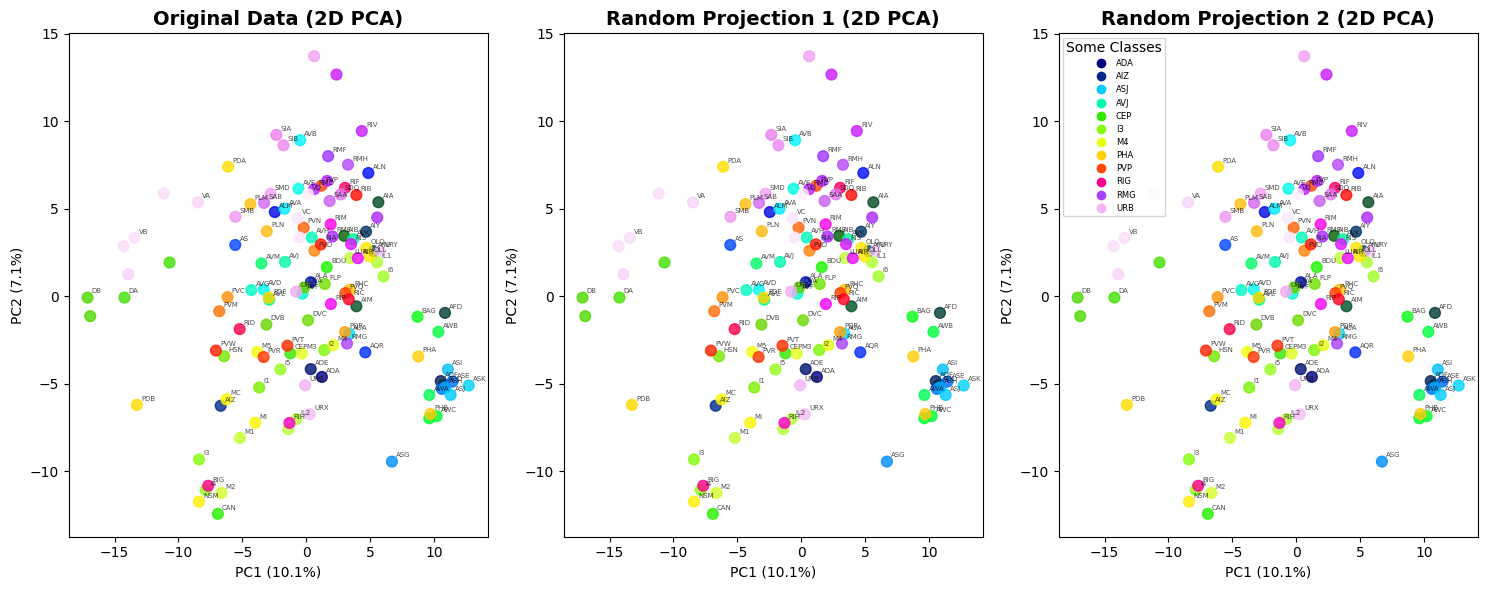

In [12]:
# Visualize with 2D PCA for both samples
pca1_2d = PCA(n_components=2, random_state=42)
pca2_2d = PCA(n_components=2, random_state=43)

# Fit PCA on first sample and transform both
rp_sample1_pca = pca1_2d.fit_transform(rp_sample1)
rp_sample2_pca = pca2_2d.fit_transform(rp_sample2)

# Create comparison plot
fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(15, 6))

# Prepare metadata color mappings
unique_cls = np.sort(np.unique(neuron_classes))
cls_to_color = {cls: i/len(unique_cls) for i, cls in enumerate(unique_cls)}

# Use gist_ncar colormap for classes since it can handle many distinct values
cls_cmap = plt.cm.gist_ncar

# Plot original data
colors = [cls_cmap(cls_to_color[cls]) for cls in neuron_classes]
scatter0 = ax0.scatter(X_pca[:, 0], X_pca[:, 1], 
                      c=colors, s=60, alpha=0.8)
ax0.set_title('Original Data (2D PCA)', fontsize=14, fontweight='bold')
ax0.set_xlabel(f'PC1 ({pca_preprocess.explained_variance_ratio_[0]:.1%})')
ax0.set_ylabel(f'PC2 ({pca_preprocess.explained_variance_ratio_[1]:.1%})')

# Plot sample 1
scatter1 = ax1.scatter(rp_sample1_pca[:, 0], rp_sample1_pca[:, 1], 
                      c=colors, s=60, alpha=0.8)
ax1.set_title('Random Projection 1 (2D PCA)', fontsize=14, fontweight='bold')
ax1.set_xlabel(f'PC1 ({pca1_2d.explained_variance_ratio_[0]:.1%})')
ax1.set_ylabel(f'PC2 ({pca1_2d.explained_variance_ratio_[1]:.1%})')

# Plot sample 2
scatter2 = ax2.scatter(rp_sample2_pca[:, 0], rp_sample2_pca[:, 1], 
                      c=colors, s=60, alpha=0.8)
ax2.set_title('Random Projection 2 (2D PCA)', fontsize=14, fontweight='bold')
ax2.set_xlabel(f'PC1 ({pca2_2d.explained_variance_ratio_[0]:.1%})')
ax2.set_ylabel(f'PC2 ({pca2_2d.explained_variance_ratio_[1]:.1%})')

# For each unique class, find one representative point and add text annotation
for cls in unique_cls:
    # Find indices where this class appears
    cls_indices = np.where(neuron_classes == cls)[0]
    if len(cls_indices) > 0:
        # Take the first occurrence as representative
        idx = cls_indices[0]
        # Add text annotation with small offset
        ax0.annotate(cls, (X_pca[idx, 0], X_pca[idx, 1]),
                    xytext=(3, 3), textcoords='offset points',
                    fontsize=5, alpha=0.7)
        ax1.annotate(cls, (rp_sample1_pca[idx, 0], rp_sample1_pca[idx, 1]),
                    xytext=(3, 3), textcoords='offset points',
                    fontsize=5, alpha=0.7)
        ax2.annotate(cls, (rp_sample2_pca[idx, 0], rp_sample2_pca[idx, 1]),
                    xytext=(3, 3), textcoords='offset points',
                    fontsize=5, alpha=0.7)

# Add legend for subset of classes
k = len(unique_cls) // 12 + 1  # Show ~12 classes
selected_classes = unique_cls[::k]
handles = [plt.Line2D([0], [0], marker='o', color='w',
                     markerfacecolor=cls_cmap(cls_to_color[cls]),
                     markersize=8, label=cls) for cls in selected_classes]
ax2.legend(handles=handles, loc='best', fontsize=6, title='Some Classes')

plt.tight_layout()
plt.show()

## Attention Model Architecture with Random Dropout Masking

We implement the `SingleHeadSelfAttention` module that learns to reconstruct each neuron's embedding using only the embeddings of other neurons. The key innovations are:
1. Diagonal masking that prevents self-attention
2. Random dropout masking during training that forces robust attention patterns

**Architecture**:
- Input: (batch, N, D) tensor of neuron embeddings
- Output: reconstructed embeddings and attention weights
- Diagonal mask: A[i,i] = 0 (prevent self-attention)
- Random dropout mask: During training, randomly mask 1 additional neuron per row to prevent overfitting


In [13]:
class SingleHeadSelfAttention(nn.Module):
    def __init__(self, d_model, n_hidden, use_attention_scores=False, verbose_timing=False):
        """
        A single head of self-attention that projects input tokens to queries, keys and values.
        The value projection implements an identity function (i.e. the values `V` will equal the input `x`) 
        so no output projection needed.
        
        Args:
            d_model: the dimension of the input tokens (D)
            n_hidden: the hidden dimension for Q/K projections
            use_attention_scores: if True, use raw attention scores instead of softmax weights
            verbose_timing: if True, print timing information for each step
        """
        super().__init__()
        # Q, K, and V projections
        self.W_Q = nn.Linear(d_model, n_hidden, bias=False)  # Query projection
        self.W_K = nn.Linear(d_model, n_hidden, bias=False)  # Key projection
        self.W_V = nn.Identity()  # Value projection; Using Identity means values = inputs
        # NOTE: If we were to use multiple heads: 
        # W_Q and W_K would be torch.nn.Linear(d_model, n_hidden*num_heads, bias=False)
        # W_V would be num_heads Identity matrices vertically stacked 
        #     i.e. matrix shape (output_dim, input_dim) = (num_heads*d_model, d_model)
        #     id = torch.eye(d_model); param = torch.nn.Parameter( torch.concat( num_heads * (id, ) ), requires_grad=False )
        #     W_V = torch.nn.Linear(d_model, num_heads*d_model, bias=False); W_V.weight = param; 
        #     Just to make sure: [ param.requires_grad_(False) for param in W_V.parameters() ]
        self.d_model = d_model
        self.n_hidden = n_hidden
        self.use_attention_scores = use_attention_scores
        self.verbose_timing = verbose_timing

    def forward(self, x, attn_mask=None, attn_dropout=0.0):
        """
        NOTE: Tokens in are the same shape as the tokens out (batch, n_neurons, d_model).
        Args:
            x: input token tensor (i.e. embeddings) of shape (batch, n_neurons, d_model)
            attn_mask: optional mask tensor of shape (batch, n_neurons, n_neurons); defaults to diagonal 'self' mask.
            attn_dropout: float between 0 and 1, fraction of neurons to randomly mask per row

        Returns:
            dict containing:
                - output: reconstructed embeddings of shape (batch, n_neurons, d_model)
                - attn_weights: attention weights of shape (batch, n_neurons, n_neurons)
                - attn_scores: attention scores of shape (batch, n_neurons, n_neurons)
                - attn_mask: attention mask of shape (batch, n_neurons, n_neurons)
        """
        start_time = time.time()
        batch_size, n_neurons, d_model = x.shape
        device = x.device

        # Compute Q, K, V projections
        Q = self.W_Q(x)  # (batch, n_neurons, n_hidden)
        K = self.W_K(x)  # (batch, n_neurons, n_hidden)
        V = self.W_V(x)  # (batch, n_neurons, d_model)
        # # NOTE: If we were to use multiple heads:
        # Q = self.W_Q(x).view((batch, n_neurons, -1, self.n_hidden)).transpose(1, 2) # (batch, num_heads, n_neurons, n_hidden)
        # K = self.W_K(x).view((batch, n_neurons, -1, self.n_hidden)).transpose(1, 2) # (batch, num_heads, n_neurons, n_hidden)
        # V = self.W_V(x).view((batch, n_neurons, -1, self.d_model)).transpose(1, 2) # (batch, num_heads, n_neurons, d_model)
        print(f"QK/V projections done in {time.time() - start_time:.3f}s") if self.verbose_timing else None

        # Create base diagonal mask (1 everywhere except diagonal)
        mask_time = time.time()
        if attn_mask is None:
            attn_mask = (1 - torch.eye(n_neurons, device=device)).unsqueeze(0).expand(batch_size, -1, -1)
        
        # Apply attention dropout if specified
        if attn_dropout > 0:
            # Calculate number of neurons to mask per row
            n_mask = int(attn_dropout * n_neurons)
            if n_mask > 0:
                # Clone mask to avoid modifying the original
                attn_mask = attn_mask.clone()
                
                # Generate random permutations for all batch x neurons at once
                # Shape: (batch_size, n_neurons, n_neurons)
                random_perms = torch.stack([torch.randperm(n_neurons, device=device) 
                                         for _ in range(batch_size * n_neurons)]).view(batch_size, n_neurons, n_neurons)
                
                # Create mask from first n_mask indices of each permutation
                dropout_mask = torch.zeros((batch_size, n_neurons, n_neurons), device=device)
                dropout_mask.scatter_(2, random_perms[:, :, :n_mask], 1)
                
                # Apply dropout mask to attention mask
                attn_mask = attn_mask * (1 - dropout_mask)
        
        print(f"Attention masking done in {time.time() - mask_time:.3f}s") if self.verbose_timing else None

        # Compute attention
        attn_time = time.time()
        # Compute scaled dot-product attention scores
        scores = torch.bmm(Q, K.transpose(1, 2)) / (self.n_hidden**0.5)
        
        # Apply mask by setting masked positions to -inf
        inf_masked_scores = scores.masked_fill(attn_mask == 0, float("-inf"))

        # Compute masked attention weights
        attn_weights = torch.softmax(inf_masked_scores, dim=-1)

        # We want masked scores but with 0s instead of -infs for visualization
        attn_scores = scores.masked_fill(attn_mask == 0, 0.0)
        print(f"Attention computation done in {time.time() - attn_time:.3f}s") if self.verbose_timing else None

        # Apply attention to values
        recon_time = time.time()
        if self.use_attention_scores:
            reconstructed = torch.bmm(attn_scores, V)
        else:
            reconstructed = torch.bmm(attn_weights, V)
        print(f"Reconstruction done in {time.time() - recon_time:.3f}s") if self.verbose_timing else None
        print(f"Total forward pass time: {time.time() - start_time:.3f}s") if self.verbose_timing else None

        return {
            'output': reconstructed,
            'attn_weights': attn_weights,
            'attn_scores': attn_scores,
            'attn_mask': attn_mask
        }


In [14]:
# Test the attention model
print("Testing SingleHeadSelfAttention model...")
print(f"Using device: {device}")

# Create model for transcriptomics
model_transcriptomics = SingleHeadSelfAttention(
    d_model=CONFIG_TRANSCRIPTOMICS['embedding_dim'],
    n_hidden=CONFIG_TRANSCRIPTOMICS['hidden_dim'],
    use_attention_scores=CONFIG_TRANSCRIPTOMICS['use_attention_scores']
).to(device)

print(f"\nSingleHeadSelfAttention created with {sum(p.numel() for p in model_transcriptomics.parameters()):,} parameters")
print(f"Model architecture: {model_transcriptomics}")


Testing SingleHeadSelfAttention model...
Using device: mps

SingleHeadSelfAttention created with 23,008,256 parameters
Model architecture: SingleHeadSelfAttention(
  (W_Q): Linear(in_features=22469, out_features=512, bias=False)
  (W_K): Linear(in_features=22469, out_features=512, bias=False)
  (W_V): Identity()
)



Masking without Dropout
	Time taken: 0.074s
	Attention shape: torch.Size([16, 130, 130])
	Reconstructed shape: torch.Size([16, 130, 22469])
	Reconstruction error: 19.739


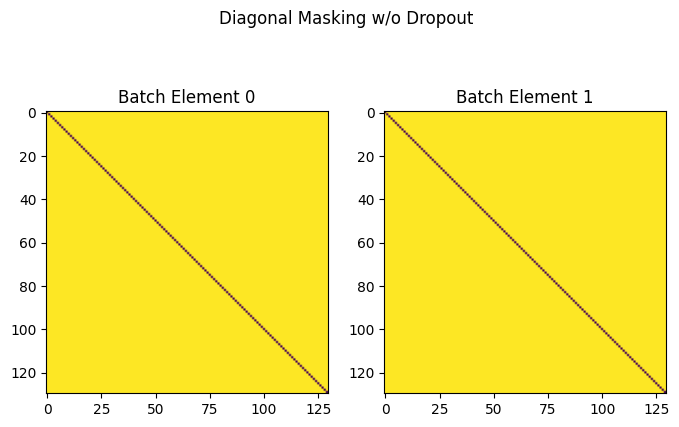


Masking with Dropout
	Time taken: 0.321s
	Attention shape: torch.Size([16, 130, 130])
	Reconstructed shape: torch.Size([16, 130, 22469])
	Reconstruction error: 19.741


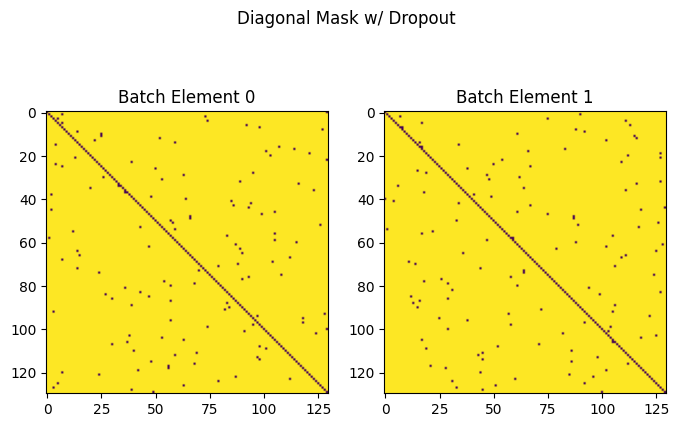

In [15]:
# Test with just the diagonal mask
model_transcriptomics.eval()
with torch.no_grad():
    start_time = time.time()
    output_regular = model_transcriptomics(rp_batch, attn_dropout=0.0)
    reconstruction_error_regular = torch.norm(rp_batch - output_regular['output'], dim=-1).mean()

print(f"\nMasking without Dropout")
print(f"\tTime taken: {time.time() - start_time:.3f}s")
print(f"\tAttention shape: {output_regular['attn_weights'].shape}")
print(f"\tReconstructed shape: {output_regular['output'].shape}")
print(f"\tReconstruction error: {reconstruction_error_regular:.3f}")

# Plot the attention mask of two batch elements to show that the diagonal masking and that it is the same for each element
fig, axes = plt.subplots(1, 2, figsize=(8, 5))
axes[0].imshow(output_regular['attn_mask'][0].cpu())
axes[0].set_title('Batch Element 0')
axes[1].imshow(output_regular['attn_mask'][1].cpu())
axes[1].set_title('Batch Element 1')
plt.suptitle('Diagonal Masking w/o Dropout')
plt.show()

# Test with additional dropout masking
model_transcriptomics.train()
with torch.no_grad():
    start_time = time.time()
    output_dropout = model_transcriptomics(rp_batch, attn_dropout=0.01)
    reconstruction_error_dropout = torch.norm(rp_batch - output_dropout['output'], dim=-1).mean()

print(f"\nMasking with Dropout")
print(f"\tTime taken: {time.time() - start_time:.3f}s")
print(f"\tAttention shape: {output_dropout['attn_weights'].shape}")
print(f"\tReconstructed shape: {output_dropout['output'].shape}")
print(f"\tReconstruction error: {reconstruction_error_dropout:.3f}")

# Plot the attention mask of two batch elements to show that the dropout and that it is different for each element
fig, axes = plt.subplots(1, 2, figsize=(8, 5))
axes[0].imshow(output_dropout['attn_mask'][0].cpu())
axes[0].set_title('Batch Element 0')
axes[1].imshow(output_dropout['attn_mask'][1].cpu())
axes[1].set_title('Batch Element 1')
plt.suptitle('Diagonal Mask w/ Dropout')
plt.show()


## Deep Transformer Decoder Architecture

### Overview
We implement a deep Transformer decoder architecture with stacked decoder blocks, each containing masked self-attention, feed-forward MLP, and layer normalization with residual connections using the **pre-norm** style.

### Decoder Block Architecture (Pre-Norm Style)
Each decoder block follows this architecture:
1. **LayerNorm → Masked Self-Attention → Residual**
2. **LayerNorm → MLP (Feed-Forward) → Residual**

### Why Pre-Norm?
- **Training Stability**: Pre-norm architectures are more stable during training
- **Better Gradient Flow**: Layer normalization before each sub-layer improves gradient flow
- **Modern Standard**: Most recent Transformer implementations use pre-norm

### Components
- **Masked Self-Attention**: Uses our `SingleHeadSelfAttention` with diagonal masking
- **MLP**: 2-layer feed-forward network with GELU activation and expansion factor (default 4x)
- **Layer Normalization**: Applied before each sub-layer (pre-norm style)
- **Residual Connections**: Skip connections around each sub-layer

### Usage
- **Shallow Model** (`n_layers=1`): Equivalent to `SingleHeadSelfAttention` + MLP
- **Deep Model** (`n_layers>1`): Stacked decoder blocks for more complex representations

### Transformer Decoder
![Decoder Architecture](figures/transformer_decoder.png)



In [16]:
class DecoderBlock(nn.Module):
    def __init__(self, d_model, n_hidden, mlp_expansion=4, dropout=0.1, 
                 use_attention_scores=False, verbose_timing=False):
        """
        A single Transformer decoder block with pre-norm architecture.
        
        Architecture:
        1. LayerNorm → Masked Self-Attention → Residual
        2. LayerNorm → MLP (Feed-Forward) → Residual
        
        Args:
            d_model: dimension of input/output embeddings
            n_hidden: hidden dimension for Q/K projections in attention
            mlp_expansion: expansion factor for MLP hidden layer (default 4x)
            dropout: dropout rate for MLP
            use_attention_scores: if True, use raw scores instead of softmax weights
            verbose_timing: if True, print timing information
        """
        super().__init__()
        
        # Layer normalization
        self.input_layernorm = nn.LayerNorm(d_model)
        self.post_attention_layernorm = nn.LayerNorm(d_model)
        
        # Masked self-attention
        self.self_attn = SingleHeadSelfAttention(
            d_model=d_model,
            n_hidden=n_hidden,
            use_attention_scores=use_attention_scores,
            verbose_timing=verbose_timing
        )
        
        # Feed-forward MLP (2-layer with expansion)
        mlp_hidden = d_model * mlp_expansion
        self.mlp = nn.Sequential(
            nn.Linear(d_model, mlp_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, d_model),
            nn.Dropout(dropout)
        )
        
        self.dropout = dropout
    
    def forward(self, x, attn_mask=None, attn_dropout=0.0):
        """
        Forward pass with a pre-norm architecture.
        
        Args:
            x: input tensor (batch, n_neurons, d_model)
            attn_mask: optional attention mask (batch, n_neurons, n_neurons)
            attn_dropout: dropout rate for attention masking
        
        Returns:
            dict with keys:
                - 'output': output tensor (batch, n_neurons, d_model)
                - 'attn_weights': attention weights (batch, n_neurons, n_neurons)
                - 'attn_scores': attention scores (batch, n_neurons, n_neurons)
                - 'attn_mask': attention mask (batch, n_neurons, n_neurons)
        """
        # LayerNorm → Attention → Residual
        residual = x
        x_norm = self.input_layernorm(x) # Pre-attention layer norm
        attn_output = self.self_attn(x, attn_mask=attn_mask, attn_dropout=attn_dropout)
        x = residual + attn_output['output']
        
        # LayerNorm → MLP → Residual
        residual = x
        x_norm = self.post_attention_layernorm(x) # Post-attention / Pre-MLP layer norm
        mlp_output = self.mlp(x_norm)
        x = residual + mlp_output
        
        return {
            'output': x,
            'attn_weights': attn_output['attn_weights'],
            'attn_scores': attn_output['attn_scores'],
            'attn_mask': attn_output['attn_mask']
        }


In [17]:
# Test DecoderBlock
print("\n1. Testing DecoderBlock...")
decoder_block = DecoderBlock(
    d_model=512,
    n_hidden=256,
    mlp_expansion=3,
    dropout=0.1,
    use_attention_scores=False,
    verbose_timing=False
).to(device)

# Test with sample input
test_input = torch.randn(4, 130, 512).to(device)  # batch=4, n_neurons=130, d_model=512
print(f"Input shape: {test_input.shape}")

# Forward pass
decoder_output = decoder_block(test_input, attn_dropout=0.01)
print(f"DecoderBlock output shape: {decoder_output['output'].shape}")
print(f"DecoderBlock attention weights shape: {decoder_output['attn_weights'].shape}")
print(f"DecoderBlock parameters: {sum(p.numel() for p in decoder_block.parameters()):,}")



1. Testing DecoderBlock...
Input shape: torch.Size([4, 130, 512])
DecoderBlock output shape: torch.Size([4, 130, 512])
DecoderBlock attention weights shape: torch.Size([4, 130, 130])
DecoderBlock parameters: 1,839,104


In [18]:
class DeepConnectomeTransformer(nn.Module):
    def __init__(self, d_model, n_hidden, n_layers=1, mlp_expansion=4, 
                 dropout=0.1, use_attention_scores=False, verbose_timing=False):
        """
        Deep Transformer with stacked decoder blocks for connectome learning.
        
        Args:
            d_model: dimension of input/output embeddings
            n_hidden: hidden dimension for Q/K projections in attention
            n_layers: number of decoder blocks to stack
            mlp_expansion: expansion factor for MLP hidden layers
            dropout: dropout rate for MLP layers
            use_attention_scores: if True, use raw scores instead of softmax weights
            verbose_timing: if True, print timing information
        """
        super().__init__()
        
        self.n_layers = n_layers
        self.d_model = d_model
        
        # Stack of decoder blocks
        self.layers = nn.ModuleList([
            DecoderBlock(
                d_model=d_model,
                n_hidden=n_hidden,
                mlp_expansion=mlp_expansion,
                dropout=dropout,
                use_attention_scores=use_attention_scores,
                verbose_timing=verbose_timing
            )
            for _ in range(n_layers)
        ])
    
    def forward(self, x, attn_mask=None, attn_dropout=0.0, return_all_layers=False):
        """
        Forward pass through all decoder blocks.
        
        Args:
            x: input tensor (batch, n_neurons, d_model)
            attn_mask: optional attention mask (batch, n_neurons, n_neurons)
            attn_dropout: dropout rate for attention masking (applied at each layer)
            return_all_layers: if True, return attention info from all layers
        
        Returns:
            dict with keys:
                - 'output': final output tensor (batch, n_neurons, d_model)
                - 'attn_weights': attention weights from last layer (or list if return_all_layers=True)
                - 'attn_scores': attention scores from last layer (or list if return_all_layers=True)
                - 'attn_mask': attention mask from last layer (or list if return_all_layers=True)
        """
        all_attn_weights = []
        all_attn_scores = []
        all_attn_masks = []
        
        # Pass through each decoder block
        for layer in self.layers:
            layer_output = layer(x, attn_mask=attn_mask, attn_dropout=attn_dropout)
            x = layer_output['output']
            
            if return_all_layers:
                all_attn_weights.append(layer_output['attn_weights'])
                all_attn_scores.append(layer_output['attn_scores'])
                all_attn_masks.append(layer_output['attn_mask'])
        
        if return_all_layers:
            return {
                'output': x,
                'attn_weights': all_attn_weights,
                'attn_scores': all_attn_scores,
                'attn_mask': all_attn_masks
            }
        else:
            # Return only the last layer's attention info
            return {
                'output': x,
                'attn_weights': layer_output['attn_weights'],
                'attn_scores': layer_output['attn_scores'],
                'attn_mask': layer_output['attn_mask']
            }


In [19]:
# Test DeepConnectomeTransformer
print("\n2. Testing DeepConnectomeTransformer...")
deep_transformer = DeepConnectomeTransformer(
    d_model=512,
    n_hidden=256,
    n_layers=2, 
    mlp_expansion=3,
    dropout=0.1,
    use_attention_scores=False,
    verbose_timing=False
).to(device)

# Forward pass
transformer_output = deep_transformer(test_input, attn_dropout=0.01)
print(f"DeepConnectomeTransformer output shape: {transformer_output['output'].shape}")
print(f"DeepConnectomeTransformer attention weights shape: {transformer_output['attn_weights'].shape}")
print(f"DeepConnectomeTransformer parameters: {sum(p.numel() for p in deep_transformer.parameters()):,}")

# Test return_all_layers
print("\n3. Testing return_all_layers=True...")
transformer_output = deep_transformer(test_input, attn_dropout=0.01, return_all_layers=True)
print(f"Number of layers: {len(transformer_output['attn_weights'])}")
print(f"Attention weights from each layer: {[w.shape for w in transformer_output['attn_weights']]}")



2. Testing DeepConnectomeTransformer...
DeepConnectomeTransformer output shape: torch.Size([4, 130, 512])
DeepConnectomeTransformer attention weights shape: torch.Size([4, 130, 130])
DeepConnectomeTransformer parameters: 3,678,208

3. Testing return_all_layers=True...
Number of layers: 2
Attention weights from each layer: [torch.Size([4, 130, 130]), torch.Size([4, 130, 130])]


In [20]:
# # Using a DeepConnectomeTransformer instead of SingleHeadSelfAttention
# print("Example: Using DeepConnectomeTransformer for transcriptomics...")

# # Use DeepConnectomeTransformer (n_layers=1 is equivalent to SingleHeadSelfAttention + Add&Norm + MLP)
# model_transcriptomics = DeepConnectomeTransformer(
#     d_model=CONFIG_TRANSCRIPTOMICS['embedding_dim'],
#     n_hidden=CONFIG_TRANSCRIPTOMICS['hidden_dim'],
#     n_layers=CONFIG_TRANSCRIPTOMICS['n_layers'], 
#     mlp_expansion=CONFIG_TRANSCRIPTOMICS['mlp_expansion'],
#     dropout=CONFIG_TRANSCRIPTOMICS['dropout'],
#     use_attention_scores=CONFIG_TRANSCRIPTOMICS['use_attention_scores']
# ).to(device)

# # Test forward pass
# with torch.no_grad():
#     output = model_transcriptomics(test_batch_transcriptomics)
#     print(f"Output shape: {output['output'].shape}")
#     print(f"Attention weights shape: {output['attn_weights'].shape}")

# print(f"\nDeepConnectomeTransformer created with {sum(p.numel() for p in model_transcriptomics.parameters()):,} parameters")
# print(f"Model architecture: {model_transcriptomics}")


## Training Loop with Reconstruction Loss and Train/Val Split

We train the attention model to minimize the reconstruction error between original and reconstructed embeddings. The key insight is that the model must learn to combine information from other neurons to reconstruct each neuron's embedding, with the learned attention weights representing the "connectome".

We now use proper train/validation split with different random projections for each set.


#### Batch Consistency Regularization

We implement a batch consistency regularization to encourage similar attention matrices across samples in the batch because in our task each batch is just a collection of views (projections) of the same underlying trasncriptome data. 

In [21]:
# Batch Consistency Loss Functions
def batch_consistency_loss_frobenius(attn_matrices, weight=1.0, reduction='mean'):
    """
    Minimize pairwise Frobenius norms between attention matrices in batch.
    Uses pdist for efficient computation of all pairwise distances.
    
    Args:
        attn_matrices: (B, N, N) tensor
        weight: scalar weight for the loss
        reduction: 'mean' or 'sum'
    
    Returns:
        scalar loss: mean or sum of pairwise Frobenius norms
    """
    B, N, _ = attn_matrices.shape
    
    # Flatten each matrix: (B, N*N)
    flat = attn_matrices.view(B, -1)
    
    # Compute pairwise Euclidean distances (equivalent to Frobenius norms)
    if device.type == 'mps':
        # NOTE: 'aten::_pdist_forward' is not currently implemented for the MPS device so move to CPU
        pairwise_distances = nn.functional.pdist(flat.cpu(), p=2) # Does this affect the gradients?
    else:
        pairwise_distances = nn.functional.pdist(flat, p=2)
    
    if reduction == 'mean':
        return weight * pairwise_distances.mean()
    elif reduction == 'sum':
        return weight * pairwise_distances.sum()
    else:
        raise ValueError(f"reduction must be 'mean' or 'sum', got {reduction}")
    
def batch_consistency_loss_variance(attn_matrices, weight=1.0, reduction='mean'):
    """
    Compute variance across batch dimension to encourage consistency.
    This is the recommended/default approach.
    
    Args:
        attn_matrices: (B, N, N) tensor of attention weights or scores
        reduction: 'mean' or 'sum'
    
    Returns:
        scalar loss: variance across batch dimension, averaged over all (i,j) pairs
    """
    # Compute variance across batch dimension for each (i,j) position
    # var(dim=0) gives (N, N) tensor of variances
    batch_variance = torch.var(attn_matrices, dim=0, unbiased=False)  # (N, N)
    
    if reduction == 'mean':
        return weight * batch_variance.mean()  # Average variance across all positions
    elif reduction == 'sum':
        return weight * batch_variance.sum()
    else:
        raise ValueError(f"reduction must be 'mean' or 'sum', got {reduction}")



In [22]:
# Set the total train and val samples and embedding dim
n_train_samples = CONFIG_TRANSCRIPTOMICS['num_samples']
n_val_samples = CONFIG_TRANSCRIPTOMICS['batch_size'] # Single batch validation
embedding_dim = CONFIG_TRANSCRIPTOMICS['embedding_dim']

# Create datasets
print(f"Creating training and validation datasets: {n_train_samples} train, {n_val_samples} val samples")
train_dataset_transcriptomics = TranscriptomeGaussianProjectionDataset(
    X_original=X_original,
    num_samples=n_train_samples,
    embedding_dim=embedding_dim,
    seed=42,
    precompute=False
)

val_dataset_transcriptomics = TranscriptomeGaussianProjectionDataset(
    X_original=X_original,
    num_samples=n_val_samples,
    embedding_dim=embedding_dim,
    seed=42 + n_train_samples, # Different seed for validation
    precompute=True  
)


Creating training and validation datasets: 9600 train, 16 val samples
GaussianProjectionDataset: 130 neurons, 22469 → 22469 dims, 9600 samples
GaussianProjectionDataset: 130 neurons, 22469 → 22469 dims, 16 samples
Precomputed 16 samples in 0.02 seconds (0.00 seconds per sample)


In [24]:
# Updated training function with dictionary unpacking
def train_attention_model(model, train_dataset, val_dataset, config, device):
    """
    Updated training function using dictionary unpacking for model outputs.
    """
    # Set up training
    criterion = nn.L1Loss() # nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=config['learning_rate'])
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=50)
    
    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=config['batch_size'], shuffle=False)
    
    # Set up consistency loss function using partial
    consistency_type = config['consistency_type']
    consistency_weight = config['consistency_weight']
    
    if consistency_type == 'frobenius':
        batch_consistency_loss_fn = partial(batch_consistency_loss_frobenius, weight=consistency_weight, reduction='mean')
    elif consistency_type == 'variance':
        batch_consistency_loss_fn = partial(batch_consistency_loss_variance, weight=consistency_weight, reduction='mean')
    else:
        raise ValueError(f"Unknown consistency_type: {consistency_type}")
    
    if consistency_weight == 0:
        batch_consistency_loss_fn = lambda x: torch.tensor(0.0, device=x.device)
    
    # Track losses
    history = {
        'train_losses': [],
        'train_recon_losses': [],
        'train_consist_losses': [],
        'val_losses': [],
        'batch_numbers': []
    }
    
    # Training loop
    total_batches = 0
    start_time = time.time()
    
    for batch_idx, train_batch in enumerate(train_loader):
        total_batches += 1
        train_batch = train_batch.to(device)
        
        # Forward pass - Use dictionary unpacking
        model.train()
        train_outputs = model(train_batch, attn_dropout=config['attn_dropout'])
        train_reconstructed = train_outputs['output']
        train_attn_weights = train_outputs['attn_weights']
        train_attn_scores = train_outputs['attn_scores']
        train_attn_mask = train_outputs['attn_mask']
        
        # Reconstruction loss
        recon_loss = criterion(train_reconstructed, train_batch)
        
        # Batch consistency loss 
        consist_loss = batch_consistency_loss_fn(train_attn_scores if config['use_attention_scores'] else train_attn_weights) # Regularization term
        
        train_loss = recon_loss + consist_loss
        
        # Backward pass
        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()
        
        # Track losses
        history['train_losses'].append(train_loss.item())
        history['train_recon_losses'].append(recon_loss.item())
        history['train_consist_losses'].append(consist_loss.item())
        history['batch_numbers'].append(total_batches)
        
        # Validation - Use dictionary unpacking
        model.eval()
        batch_val_losses = []
        with torch.no_grad():
            for val_batch in val_loader:
                val_batch = val_batch.to(device)
                val_outputs = model(val_batch, attn_dropout=0.0) # No attention dropout at validation
                val_reconstructed = val_outputs['output']
                val_attn_weights = val_outputs['attn_weights']
                val_attn_scores = val_outputs['attn_scores']
                val_attn_mask = val_outputs['attn_mask']
                val_loss = criterion(val_reconstructed, val_batch) + batch_consistency_loss_fn(val_attn_scores if config['use_attention_scores'] else val_attn_weights)
                batch_val_losses.append(val_loss.item())
        
        avg_val_loss = np.mean(batch_val_losses)
        history['val_losses'].append(avg_val_loss)
        scheduler.step(avg_val_loss)
        
        # Print progress
        if (batch_idx + 1) % 10 == 0:
            elapsed_time = time.time() - start_time
            print(f"Batch {batch_idx + 1}: Train Loss = {train_loss.item():.6f}, "
                  f"Val Loss = {avg_val_loss:.6f}, LR = {scheduler.get_last_lr()[0]:.6f}, "
                  f"Time = {elapsed_time:.2f}s")
            start_time = time.time()
    
    return history



Training attention model on transcriptomics...

Batch 10: Train Loss = 0.026970, Val Loss = 0.026637, LR = 0.001000, Time = 1.10s
Batch 20: Train Loss = 0.024101, Val Loss = 0.024051, LR = 0.001000, Time = 0.98s
Batch 30: Train Loss = 0.023061, Val Loss = 0.023030, LR = 0.001000, Time = 0.95s
Batch 40: Train Loss = 0.022569, Val Loss = 0.022528, LR = 0.001000, Time = 0.94s
Batch 50: Train Loss = 0.022282, Val Loss = 0.022276, LR = 0.001000, Time = 0.93s
Batch 60: Train Loss = 0.022111, Val Loss = 0.022117, LR = 0.001000, Time = 0.92s
Batch 70: Train Loss = 0.022184, Val Loss = 0.022044, LR = 0.001000, Time = 0.94s
Batch 80: Train Loss = 0.021890, Val Loss = 0.021894, LR = 0.001000, Time = 0.94s
Batch 90: Train Loss = 0.021804, Val Loss = 0.021795, LR = 0.001000, Time = 0.94s
Batch 100: Train Loss = 0.021734, Val Loss = 0.021727, LR = 0.001000, Time = 0.95s
Batch 110: Train Loss = 0.021807, Val Loss = 0.021731, LR = 0.001000, Time = 0.93s
Batch 120: Train Loss = 0.021660, Val Loss = 0.

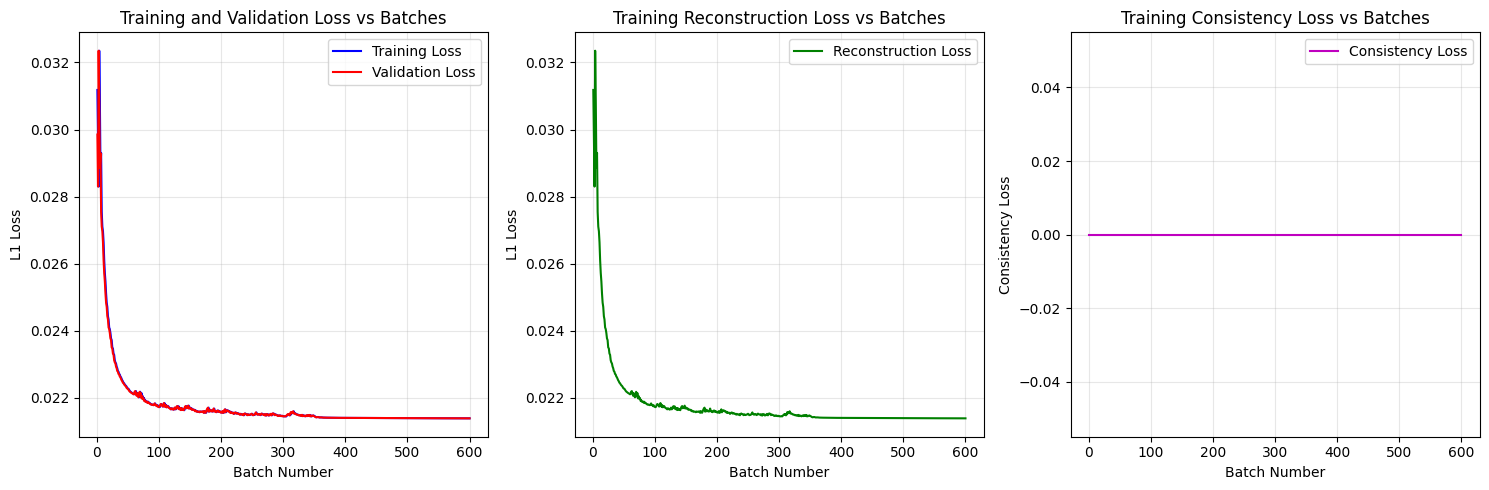

In [25]:
# Train the model using the fixed training function
print("\n" + "="*80)
print("Training attention model on transcriptomics...")
print("="*80 + "\n")

history_transcriptomics = train_attention_model(
    model=model_transcriptomics,
    train_dataset=train_dataset_transcriptomics,
    val_dataset=val_dataset_transcriptomics,
    config=CONFIG_TRANSCRIPTOMICS,
    device=device
)

# Plot training curves
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(history_transcriptomics['batch_numbers'], history_transcriptomics['train_losses'], 'b-', label='Training Loss')
plt.plot(history_transcriptomics['batch_numbers'], history_transcriptomics['val_losses'], 'r-', label='Validation Loss')
plt.xlabel('Batch Number')
plt.ylabel('L1 Loss')
plt.title('Training and Validation Loss vs Batches')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(history_transcriptomics['batch_numbers'], history_transcriptomics['train_recon_losses'], 'g-', label='Reconstruction Loss')
plt.xlabel('Batch Number')
plt.ylabel('L1 Loss')
plt.title('Training Reconstruction Loss vs Batches')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(history_transcriptomics['batch_numbers'], history_transcriptomics['train_consist_losses'], 'm-', label='Consistency Loss')
plt.xlabel('Batch Number')
plt.ylabel('Consistency Loss')
plt.title('Training Consistency Loss vs Batches')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Visualization of Learned Attention Matrices

Now we visualize the learned attention patterns. The attention weights represent our learned "connectome" - how much each neuron needs to attend to every other neuron for reconstruction. We'll focus on analyzing the structure and patterns in the learned attention matrix.


In [26]:
# Updated analyze_attention_matrix function with dictionary unpacking
def analyze_attention_matrix(model, dataset, neuron_labels, device, 
                            use_attention_scores=False, sparsity_thresh=0.1,
                            num_graph_sources=10):
    """
    Extract and comprehensively analyze learned attention matrix.
    
    Args:
        model: trained SingleHeadSelfAttention or DeepConnectomeTransformer model
        dataset: Dataset used for evaluation
        neuron_labels: list of neuron identifiers, must exactly correspond to order of rows in dataset
        device: torch device
        use_attention_scores: whether to use scores or weights
        sparsity_thresh: weight threshold for sparsity calculation and edges in graph visualization
        num_graph_sources: number of source neurons to highlight for graph visualization
    
    Returns:
        dict with attention matrix and comprehensive analysis results
    """
    model.eval()
    
    # Collect attention matrices from all samples
    all_attn_weights = []
    all_attn_scores = []
    loader = DataLoader(dataset, batch_size=32, shuffle=False)
    
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            # Use dictionary unpacking
            outputs = model(batch, attn_dropout=0.0)
            attn_weights = outputs['attn_weights']
            attn_scores = outputs['attn_scores']
            all_attn_weights.append(attn_weights.cpu().numpy())
            all_attn_scores.append(attn_scores.cpu().numpy())
    
    # We will average across all samples
    all_attn_weights = np.concatenate(all_attn_weights, axis=0)
    all_attn_scores = np.concatenate(all_attn_scores, axis=0)
    
    # Take mean across batch dimension; shape (num_neurons, num_neurons)
    attention_weights_matrix = np.mean(all_attn_weights, axis=0)
    attention_scores_matrix = np.mean(all_attn_scores, axis=0)
    
    # Choose which matrix to analyze
    if use_attention_scores:
        attention_matrix = attention_scores_matrix
        matrix_type = "scores"
    else:
        attention_matrix = attention_weights_matrix
        matrix_type = "weights"
    
    # Assert that matrix dimensions match number of neuron labels
    assert attention_matrix.shape[0] == len(neuron_labels), \
        f"Number of rows in attention matrix ({attention_matrix.shape[0]}) " \
        f"does not match number of neuron labels ({len(neuron_labels)})"
    
    # Basic statistics
    mean_val = np.mean(attention_matrix)
    std_val = np.std(attention_matrix)
    max_val = np.max(attention_matrix)
    # Use the weights matrix for sparsity calculation
    sparsity = np.sum(attention_weights_matrix < sparsity_thresh) / attention_weights_matrix.size 
    
    # Create visualization with 4 panels
    fig = plt.figure(figsize=(24, 18))
    
    # Create grid with two rows
    gs = plt.GridSpec(2, 2, height_ratios=[1.2, 0.8])
    
    # 1) Full attention matrix heatmap - larger and square (top left)
    ax1 = plt.subplot(gs[0, 0])
    im1 = ax1.imshow(attention_matrix, cmap='viridis', aspect='equal')
    ax1.set_title(f'Learned Attention Matrix ({matrix_type.title()})', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Source Neuron', fontsize=12)
    ax1.set_ylabel('Target Neuron', fontsize=12)
    # Set tick labels to neuron labels with larger font size
    ax1.set_xticks(np.arange(len(neuron_labels)))
    ax1.set_yticks(np.arange(len(neuron_labels)))
    ax1.set_xticklabels(neuron_labels, rotation=90, ha='right', fontsize=8)
    ax1.set_yticklabels(neuron_labels, fontsize=8)
    plt.colorbar(im1, ax=ax1, label=f'Attention {matrix_type.title()}')
    
    # 2) Network graph visualization (top right)
    ax2 = plt.subplot(gs[0, 1])
    G = nx.DiGraph()
    n_neurons = len(neuron_labels)
    
    # Add nodes
    for i, label in enumerate(neuron_labels):
        G.add_node(i, label=label)
    
    # Add edges above threshold
    edge_thresh = sparsity_thresh
    for i in range(n_neurons):  # i is target
        for j in range(n_neurons):  # j is source
            if attention_weights_matrix[i, j] > edge_thresh:
                G.add_edge(j, i, weight=attention_matrix[i, j])
    
    # Select top source neurons
    outgoing_attention = np.sum(attention_weights_matrix, axis=0)
    top_sources = np.argsort(outgoing_attention)[-num_graph_sources:]
    
    # Create subgraph
    subgraph_nodes = set(top_sources)
    for source in top_sources:
        targets = np.where(attention_weights_matrix[:, source] > edge_thresh)[0]
        subgraph_nodes.update(targets)

    subgraph = G.subgraph(subgraph_nodes)
    
    # Layout and draw
    pos = nx.spring_layout(subgraph, k=1, iterations=50)
    node_colors = ['red' if node in top_sources else 'lightblue' for node in subgraph.nodes()]
    
    nx.draw(subgraph, pos, ax=ax2, 
            node_color=node_colors,
            node_size=500,
            with_labels=True,
            labels={node: neuron_labels[node] for node in subgraph.nodes()},
            font_size=8,
            font_weight='bold',
            edge_color='gray',
            alpha=0.7)
    ax2.set_title(f'Attention Network (Top {num_graph_sources} Sources)', fontsize=14, fontweight='bold')
    
    legend_elements = [plt.Line2D([0], [0], marker='o', color='w', label='Top Source',
                                 markerfacecolor='red', markersize=10),
                      plt.Line2D([0], [0], marker='o', color='w', label='Other Neuron',
                                 markerfacecolor='lightblue', markersize=10)]
    ax2.legend(handles=legend_elements, loc='upper right')
    
    # 3) Attention distribution (bottom left)
    ax3 = plt.subplot(gs[1, 0])
    ax3.hist(attention_matrix.flatten(), bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    ax3.set_title(f'Attention {matrix_type.title()} Distribution', fontsize=14, fontweight='bold')
    ax3.set_xlabel(f'Attention {matrix_type.title()}', fontsize=12)
    ax3.set_ylabel('Frequency', fontsize=12)
    ax3.axvline(sparsity_thresh, color='red', linestyle='--', label=f'Sparsity threshold ({sparsity_thresh})')
    ax3.legend()
    
    # 4) Summary statistics text box (bottom right)
    ax4 = plt.subplot(gs[1, 1])
    ax4.axis('off')
    summary_text = f"""Attention Matrix Summary:

    Matrix Type: {matrix_type.title()}
    Shape: {attention_matrix.shape}
    Mean: {mean_val:.6f}
    Std: {std_val:.6f}
    Max: {max_val:.6f}
    Sparsity (< Threshold = {sparsity_thresh}): {sparsity:.3f}

    Network Statistics:
    Total Nodes: {len(subgraph.nodes())}
    Total Edges: {len(subgraph.edges())}
    Top Sources: {num_graph_sources}
    Edge Threshold (= Sparsity Threshold): {edge_thresh}

    Neuron Labels: {len(neuron_labels)}"""
    
    ax4.text(0.1, 0.5, summary_text, fontsize=12, verticalalignment='center',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.7))
    
    plt.tight_layout()
    plt.show()
    
    return {
        'attention_matrix': attention_matrix,
        'attention_weights': attention_weights_matrix,
        'attention_scores': attention_scores_matrix,
        'mean': mean_val,
        'std': std_val,
        'max': max_val,
        'sparsity': sparsity,
        'network': subgraph,
        'top_sources': top_sources
    }


Analyzing learned attention matrix from transcriptomics phase...


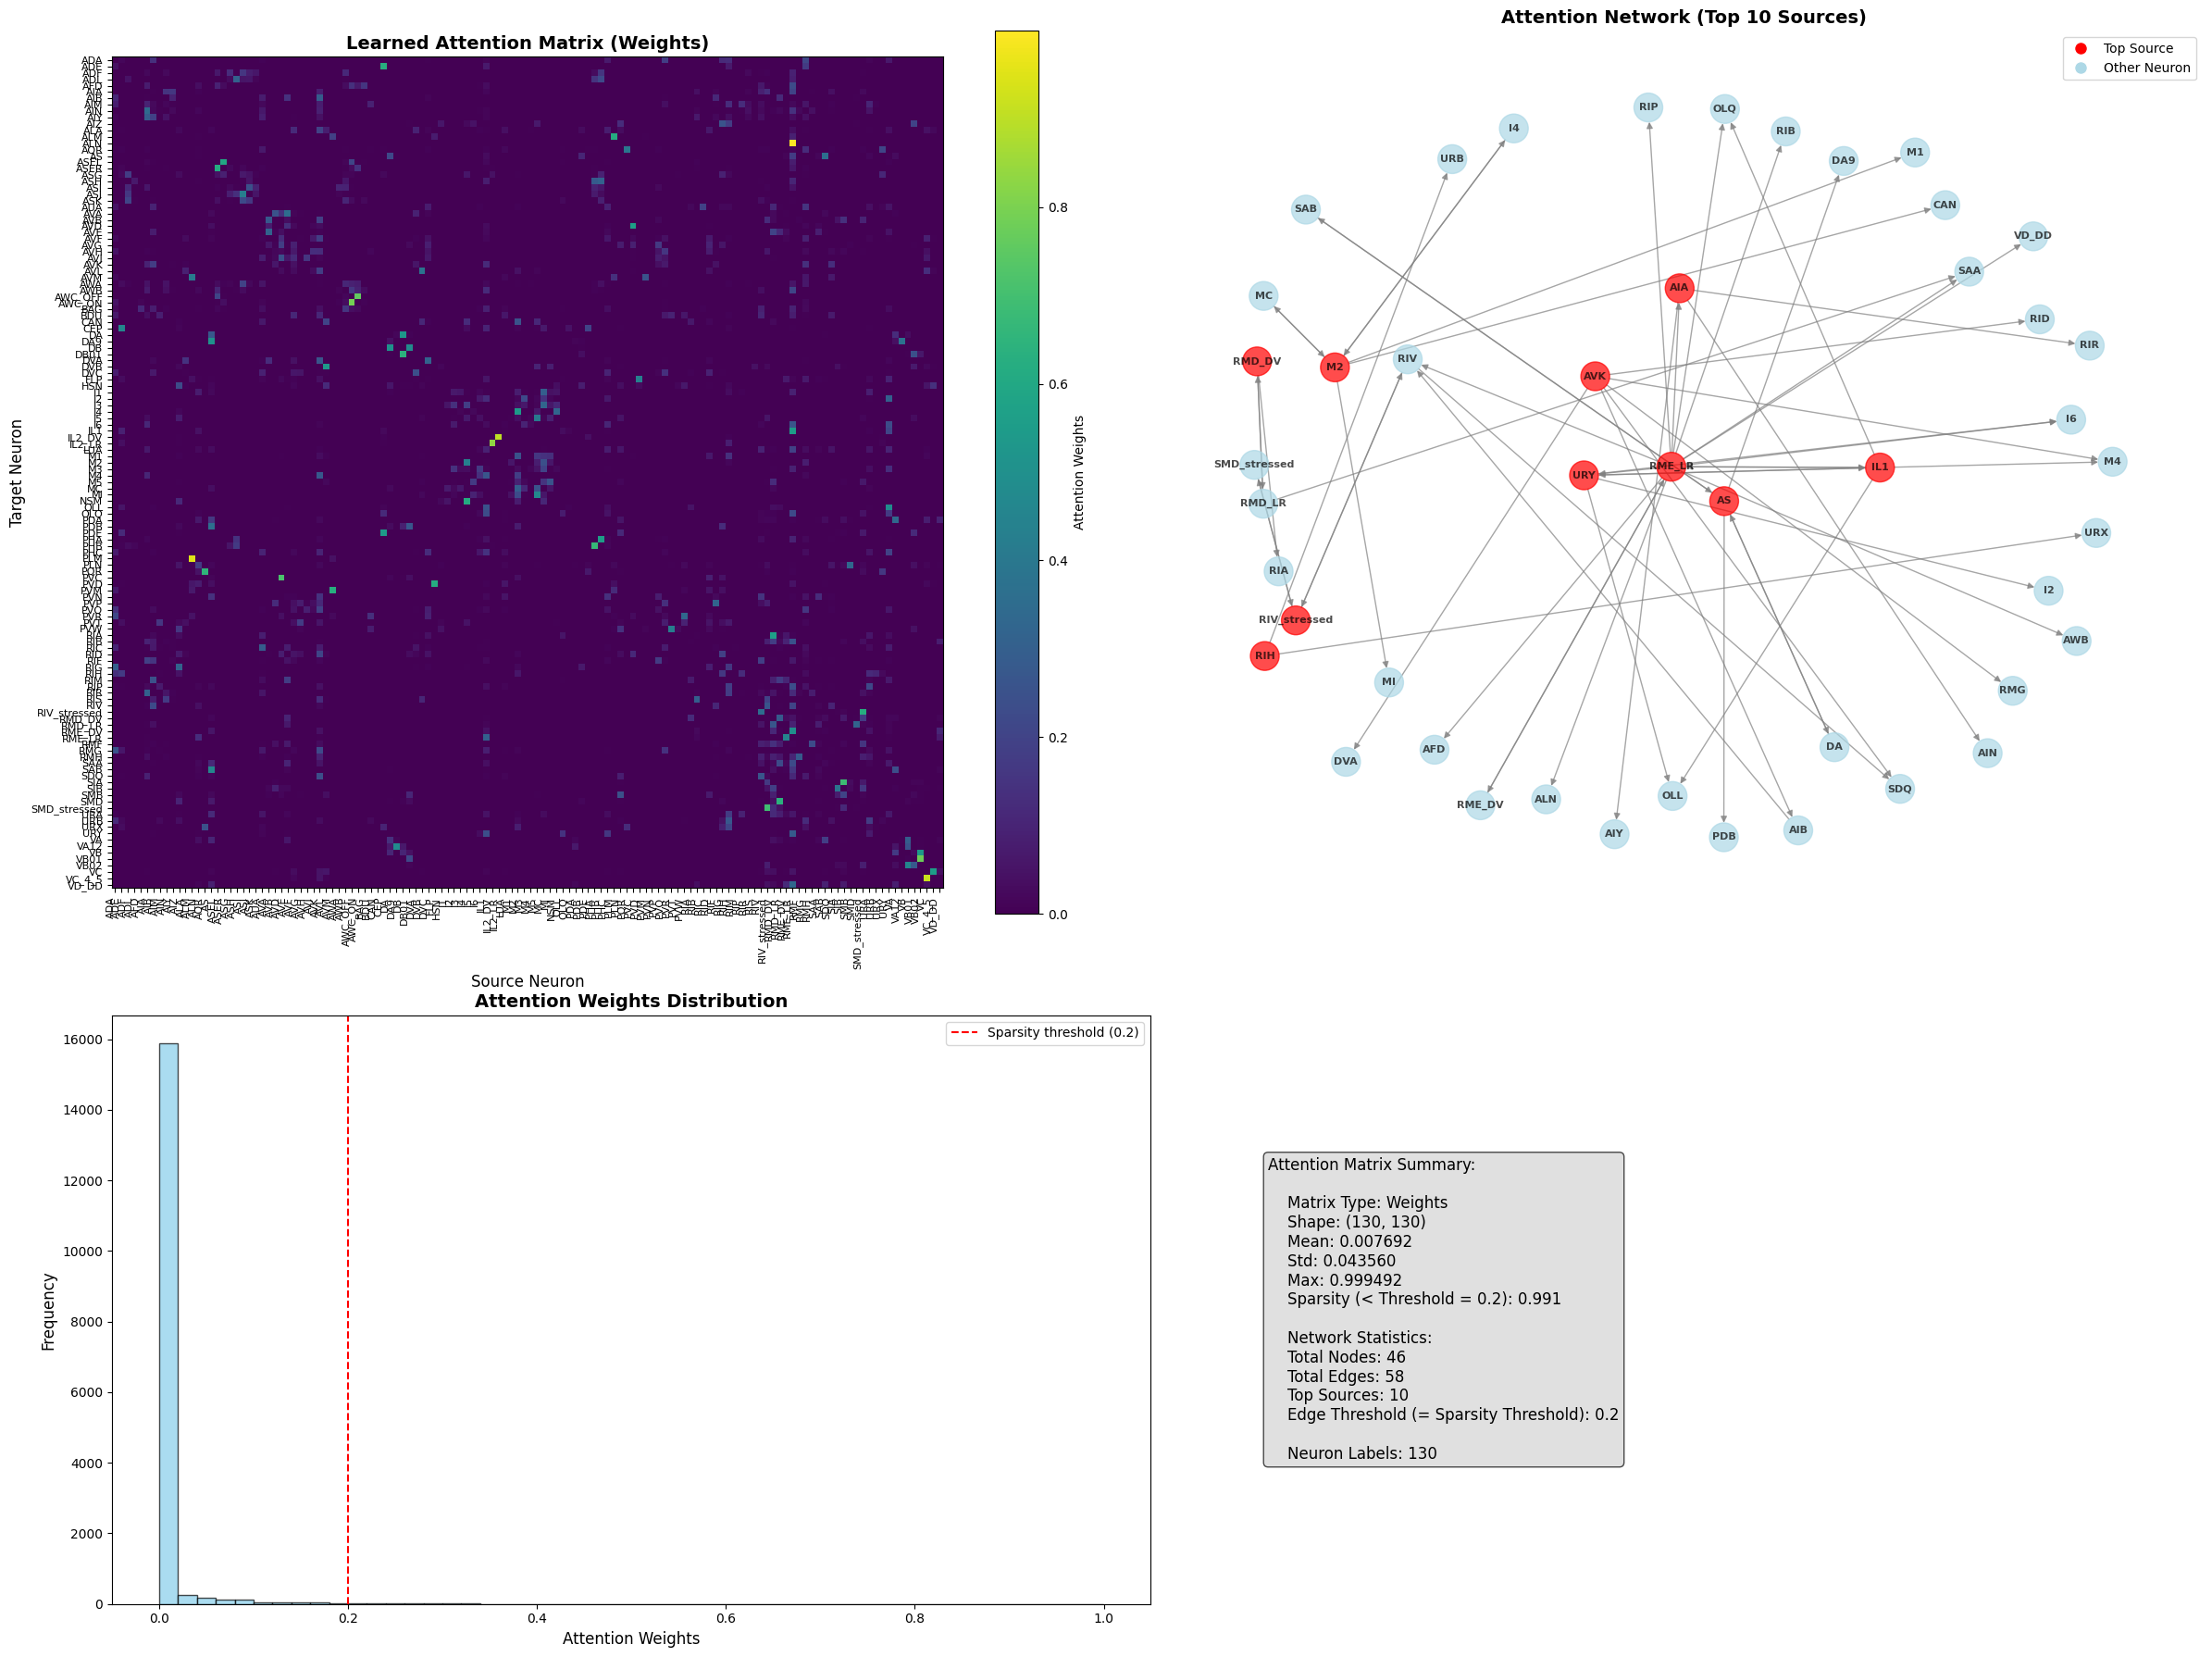


Transcriptomics Phase Results:
  Attention matrix shape: (130, 130)
  Sparsity: 0.991
  Mean attention weight: 0.007692
  Std attention weight: 0.043560


In [27]:
# Replace the transcriptomics visualization with modularized function
print("Analyzing learned attention matrix from transcriptomics phase...")

# Analyze using the comprehensive function
analysis_results_transcriptomics = analyze_attention_matrix(
    model=model_transcriptomics,
    dataset=val_dataset_transcriptomics, # test_dataset
    neuron_labels=neuron_labels,
    device=device,
    use_attention_scores=CONFIG_TRANSCRIPTOMICS['use_attention_scores'],
    sparsity_thresh=0.2,
    num_graph_sources=10,
)

attention_weights_transcriptomics = analysis_results_transcriptomics['attention_weights']
attention_scores_transcriptomics = analysis_results_transcriptomics['attention_scores']

print(f"\nTranscriptomics Phase Results:")
print(f"  Attention matrix shape: {analysis_results_transcriptomics['attention_matrix'].shape}")
print(f"  Sparsity: {analysis_results_transcriptomics['sparsity']:.3f}")
print(f"  Mean attention weight: {analysis_results_transcriptomics['mean']:.6f}")
print(f"  Std attention weight: {analysis_results_transcriptomics['std']:.6f}")


### **Idea**: Does the learned attention matrix better embed neurons? 

If we interpret the attention matrix as a similarity matrix, does it induce a semantically meaningful clustering of neurons, such as by cell-type or neurotransmitters?

We can load additional neuron metadata from `data/neuron_master_sheet.csv` to use as unsupervised labels.

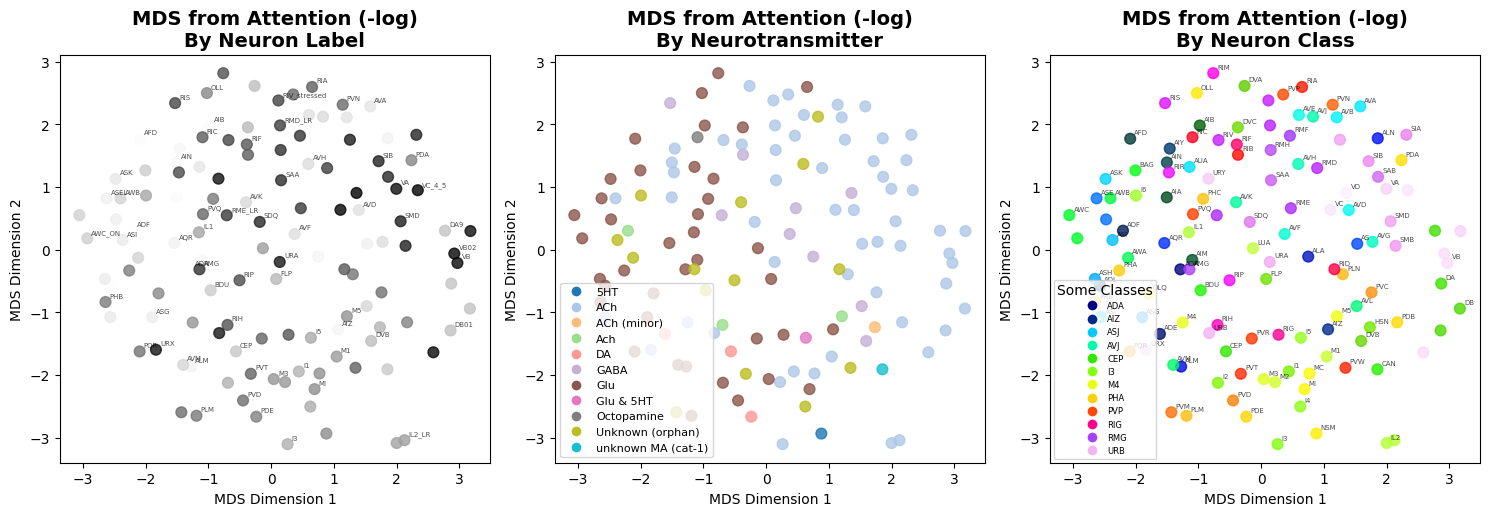

In [37]:
# Simple approach: treat learned attention matrix as similarity, 
# turn into distance, and use sklearn MDS.

# Use the learned attention matrix as similarity
A = analysis_results_transcriptomics['attention_matrix']

# Optional: symmetrize if desired (can comment out if already symmetric)
A = 0.5 * (A + A.T)

# Convert similarity to distance; use information distance, 
# which is steeper than sqrt(1-S)
eps = 1e-9
S = np.clip(A, 0, 1)        # ensure valid range
D = np.sqrt(np.maximum(0.0, -np.log(S + eps)))  # shape (N, N)

# Now run MDS. We use "precomputed" because we give the distance matrix.
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
coords_mds = mds.fit_transform(D)   # shape (N,2)

# Plot: 3 panel fig, colored by (1) neuron label, (2) neurotransmitter, (3) class
fig, axes = plt.subplots(1, 3, figsize=(15, 15))

# Prepare color maps
unique_nt = np.sort(np.unique(neuron_neurotransmitters))
nt_to_color = {nt: i/len(unique_nt) for i, nt in enumerate(unique_nt)}
unique_cls = np.sort(np.unique(neuron_classes))
cls_to_color = {cls: i/len(unique_cls) for i, cls in enumerate(unique_cls)}

label_cmap = plt.cm.Greys
nt_cmap = plt.cm.tab20
cls_cmap = plt.cm.gist_ncar

# Plot 1: colored by neuron label (index)
ax = axes[0]
scatter = ax.scatter(coords_mds[:, 0], coords_mds[:, 1],
                     c=range(len(neuron_labels)), cmap=label_cmap, s=60, alpha=0.8)
ax.set_title('MDS from Attention (-log)\nBy Neuron Label', fontsize=14, fontweight='bold')
ax.set_xlabel('MDS Dimension 1')
ax.set_ylabel('MDS Dimension 2')
ax.set_aspect('equal')

for i in range(0, len(neuron_labels), 2):
    ax.annotate(neuron_labels[i],
                (coords_mds[i, 0], coords_mds[i, 1]),
                xytext=(3, 3), textcoords='offset points',
                fontsize=5, alpha=0.7)

# Plot 2: colored by neurotransmitter
ax = axes[1]
colors = [nt_cmap(nt_to_color[nt]) for nt in neuron_neurotransmitters]
scatter = ax.scatter(coords_mds[:, 0], coords_mds[:, 1], c=colors, s=60, alpha=0.8)
ax.set_title('MDS from Attention (-log)\nBy Neurotransmitter', fontsize=14, fontweight='bold')
ax.set_xlabel('MDS Dimension 1')
ax.set_ylabel('MDS Dimension 2')
ax.set_aspect('equal')
handles = [plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=nt_cmap(nt_to_color[nt]),
                      markersize=8, label=nt) for nt in unique_nt]
ax.legend(handles=handles, loc='best', fontsize=8)

# Plot 3: colored by neuron class, text annotations for each class
ax = axes[2]
colors = [cls_cmap(cls_to_color[cls]) for cls in neuron_classes]
scatter = ax.scatter(coords_mds[:, 0], coords_mds[:, 1], c=colors, s=60, alpha=0.8)
ax.set_title('MDS from Attention (-log)\nBy Neuron Class', fontsize=14, fontweight='bold')
ax.set_xlabel('MDS Dimension 1')
ax.set_ylabel('MDS Dimension 2')
ax.set_aspect('equal')

k = len(unique_cls) // 12 + 1
selected_classes = unique_cls[::k]
handles = [plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=cls_cmap(cls_to_color[cls]),
                      markersize=8, label=cls) for cls in selected_classes]
ax.legend(handles=handles, loc='best', fontsize=6, title='Some Classes')

for cls in unique_cls:
    cls_indices = np.where(neuron_classes == cls)[0]
    if len(cls_indices) > 0:
        idx = cls_indices[0]
        ax.annotate(cls,
                    (coords_mds[idx, 0], coords_mds[idx, 1]),
                    xytext=(3, 3), textcoords='offset points',
                    fontsize=5, alpha=0.7)

plt.tight_layout()
plt.show()


## Ground-Truth Connectome Data Loading and Analysis

Now we'll load and analyze ground-truth connectome data to compare with our learned attention matrix. We have access to:

1. **Witvliet 2020 data** (`witvliet_2020_7.csv`, `witvliet_2020_8.csv`): From "Connectomes across development reveal principles of brain maturation" (Nature 596, 257–261, 2021)
2. **Cook 2019 data** (`41586_2019_1352_MOESM9_ESM.xlsx`): From "Whole-animal connectomes of both Caenorhabditis elegans sexes" (Nature 571, 63–71, 2019)
3. **Randi 2023 data** (`CElegansFunctionalConnectivity.xlsx`): From "Neural signal propagation atlas of Caenorhabditis elegans" (Nature 623, 406–414, 2023)

These provide both structural (wired) and functional connectivity data that we can compare against our learned attention patterns.

### References
> Witvliet, D., Mulcahy, B., Mitchell, J.K. et al. Connectomes across development reveal principles of brain maturation. Nature 596, 257–261 (2021). https://doi.org/10.1038/s41586-021-03778-8

> Cook, S.J., Jarrell, T.A., Brittin, C.A. et al. Whole-animal connectomes of both Caenorhabditis elegans sexes. Nature 571, 63–71 (2019). https://doi.org/10.1038/s41586-019-1352-7

> Randi, F., Sharma, A.K., Dvali, S. et al. Neural signal propagation atlas of Caenorhabditis elegans. Nature 623, 406–414 (2023). https://doi.org/10.1038/s41586-023-06683-4


In [38]:
# Load and analyze Witvliet 2020 connectome data
print("Loading Witvliet 2020 connectome data...")

# Load both datasets (they are tab-separated)
witvliet_7 = pd.read_csv('data/connectomics/witvliet_2020_7.csv', sep='\t')
witvliet_8 = pd.read_csv('data/connectomics/witvliet_2020_8.csv', sep='\t')

print(f"Witvliet 2020-7 shape: {witvliet_7.shape}")
print(f"Witvliet 2020-8 shape: {witvliet_8.shape}")
print(f"\nWitvliet 2020-7 columns: {witvliet_7.columns.tolist()}")
print(f"Witvliet 2020-8 columns: {witvliet_8.columns.tolist()}")

# Display sample data
print(f"\nWitvliet 2020-7 sample:")
print(witvliet_7.head())
print(f"\nWitvliet 2020-8 sample:")
print(witvliet_8.head())

# Analyze unique neurons in each dataset, filtering out BWM (body-wall muscle) neurons
neurons_7_pre = {n for n in witvliet_7['pre'].unique() if not n.startswith('BWM-')}
neurons_7_post = {n for n in witvliet_7['post'].unique() if not n.startswith('BWM-')}
neurons_7_all = neurons_7_pre.union(neurons_7_post)

neurons_8_pre = {n for n in witvliet_8['pre'].unique() if not n.startswith('BWM-')}
neurons_8_post = {n for n in witvliet_8['post'].unique() if not n.startswith('BWM-')}
neurons_8_all = neurons_8_pre.union(neurons_8_post)

# Union of all neurons across both datasets
neurons_7_8_all = neurons_7_all.union(neurons_8_all)

# Map class members to their class names since the neuron labels consist of a mixture of class and members
neurons_7_8_all |= {label_to_class[mem] for mem in neurons_7_8_all if mem in label_to_class}  

# Sort for consistent ordering
neurons_7_8_all = sorted(list(neurons_7_8_all))  

print(f"\nNeuron analysis:")
print(f"Witvliet 2020-7: {len(neurons_7_all)} unique neurons")
print(f"Witvliet 2020-8: {len(neurons_8_all)} unique neurons")
print(f"Union of Witvliet 2020-7 and 2020-8: {len(neurons_7_8_all)} neurons")


Loading Witvliet 2020 connectome data...
Witvliet 2020-7 shape: (2493, 4)
Witvliet 2020-8 shape: (2496, 4)

Witvliet 2020-7 columns: ['pre', 'post', 'type', 'synapses']
Witvliet 2020-8 columns: ['pre', 'post', 'type', 'synapses']

Witvliet 2020-7 sample:
    pre  post      type  synapses
0  ADAL  AIAL  chemical         2
1  ADAL  AIBL  chemical         2
2  ADAL  AIBR  chemical         1
3  ADAL  AVAL  chemical         1
4  ADAL  AVBL  chemical         7

Witvliet 2020-8 sample:
    pre  post        type  synapses
0  ADAL  ADAR  electrical         1
1  ADAL  ASHL  electrical         1
2  ADAL  AVAL    chemical         2
3  ADAL  AVAR    chemical         1
4  ADAL  AVBL    chemical        16

Neuron analysis:
Witvliet 2020-7: 190 unique neurons
Witvliet 2020-8: 187 unique neurons
Union of Witvliet 2020-7 and 2020-8: 260 neurons


In [39]:
# ============================================================================
# MODULARIZED MATRIX COMPARISON AND VISUALIZATION FUNCTIONS
# ============================================================================

def create_adjacency_matrix(connectome_df, neuron_list, weight_col='synapses', synapse_type='chemical'):
    """
    Create adjacency matrix from connectome dataframe.
    
    Args:
        connectome_df: DataFrame with columns ['pre', 'post', 'type', 'weight']
        neuron_list: List of neuron names in desired order
        weight_col: Column name for edge weights
        synapse_type: Type of synapse to include ('chemical', 'electrical', 'all')
    
    Returns:
        adjacency_matrix: (N, N) numpy array
    """
    n_neurons = len(neuron_list)
    adjacency_matrix = np.zeros((n_neurons, n_neurons))
    
    # Create mapping from neuron name to index
    neuron_to_idx = {neuron: i for i, neuron in enumerate(neuron_list)}
    
    # Filter by synapse type
    if synapse_type != 'all':
        filtered_df = connectome_df[connectome_df['type'] == synapse_type]
    else:
        filtered_df = connectome_df
    
    # Fill adjacency matrix
    for _, row in filtered_df.iterrows():
        pre_neuron = row['pre']
        post_neuron = row['post']
        weight = row[weight_col]
        
        if pre_neuron in neuron_to_idx and post_neuron in neuron_to_idx:
            pre_idx = neuron_to_idx[pre_neuron]
            post_idx = neuron_to_idx[post_neuron]
            adjacency_matrix[pre_idx, post_idx] += weight
    
    return adjacency_matrix


In [40]:
# Analyze connection types
print(f"\nConnection type analysis:")
print(f"Witvliet 2020-7 types: {witvliet_7['type'].value_counts().to_dict()}")
print(f"Witvliet 2020-8 types: {witvliet_8['type'].value_counts().to_dict()}")

# Create full adjacency matrices for all neurons in union (chemical synapses only)
print(f"\nCreating adjacency matrices for {len(neurons_7_8_all)} neurons...")

print("Witvliet 2020-7:")
gt_adj_7_full = create_adjacency_matrix(witvliet_7, neurons_7_8_all, weight_col='synapses', synapse_type='chemical')

print("Witvliet 2020-8:")
gt_adj_8_full = create_adjacency_matrix(witvliet_8, neurons_7_8_all, weight_col='synapses', synapse_type='chemical')

# Average element-wise (treating missing connections as 0)
gt_adj_combined = (gt_adj_7_full + gt_adj_8_full) / 2

# # Add small epsilon to avoid division by zero, similar to attention masking
# eps = 1e-9
# row_sums = gt_adj_combined.sum(axis=1, keepdims=True) + eps
# gt_adj_combined = gt_adj_combined / row_sums

print(f"\nCombined adjacency matrix shape: {gt_adj_combined.shape}")
print(f"Combined matrix stats - mean: {gt_adj_combined.mean():.6f}, std: {gt_adj_combined.std():.6f}, max: {gt_adj_combined.max():.1f}")



Connection type analysis:
Witvliet 2020-7 types: {'chemical': 2202, 'electrical': 291}
Witvliet 2020-8 types: {'chemical': 2186, 'electrical': 310}

Creating adjacency matrices for 260 neurons...
Witvliet 2020-7:
Witvliet 2020-8:

Combined adjacency matrix shape: (260, 260)
Combined matrix stats - mean: 0.102093, std: 0.904682, max: 36.5


In [41]:
def compare_attention_with_ground_truth(attention_matrix, attention_neuron_labels, 
                                     ground_truth_matrices, ground_truth_neuron_labels,
                                     phase_name="Unknown Phase", 
                                     label_to_class_mapping=None,
                                     exclude_bwm=True):
    """
    Comprehensive comparison between learned attention matrix and ground-truth connectomes.
    
    Args:
        attention_matrix: (N, N) learned attention matrix
        attention_neuron_labels: List of neuron labels for attention matrix
        ground_truth_matrices: Dict of {'name': matrix} for ground-truth connectomes
        ground_truth_neuron_labels: Dict of {'name': labels} for ground-truth matrices
        phase_name: String describing the phase (e.g., "Transcriptomics", "Neural Dynamics")
        label_to_class_mapping: Optional dict mapping neuron labels to class names
        exclude_bwm: Whether to exclude BWM (body-wall muscle) neurons
    
    Returns:
        results: Dict containing comparison results and visualizations
    """
    print(f"\n" + "="*80)
    print(f"Comparing Ground-Truth Connectome to Learned Attention Matrix ({phase_name.upper()})")
    print("="*80)
    
    results = {
        'phase_name': phase_name,
        'attention_matrix': attention_matrix,
        'attention_neuron_labels': attention_neuron_labels,
        'comparisons': {}
    }
    
    # Process attention neuron labels
    if exclude_bwm:
        attention_neurons = {n for n in attention_neuron_labels if not n.startswith('BWM-')}
    else:
        attention_neurons = set(attention_neuron_labels)
    
    # Apply label-to-class mapping if provided
    if label_to_class_mapping:
        attention_neurons |= {label_to_class_mapping[mem] for mem in attention_neurons 
                             if mem in label_to_class_mapping}
    
    # Compare with each ground-truth connectome
    for gt_name, gt_matrix in ground_truth_matrices.items():
        print(f"\n{'='*60}")
        print(f"Comparing {gt_name.upper()} Connectome to Attention Matrix")
        print(f"{'='*60}")
        
        gt_labels = ground_truth_neuron_labels[gt_name]
        
        # Process ground-truth neuron labels
        if exclude_bwm:
            gt_neurons = {n for n in gt_labels if not n.startswith('BWM-')}
        else:
            gt_neurons = set(gt_labels)
        
        # Apply label-to-class mapping if provided
        if label_to_class_mapping:
            gt_neurons |= {label_to_class_mapping[mem] for mem in gt_neurons 
                          if mem in label_to_class_mapping}
        
        # Find overlapping neurons
        overlap_neurons = sorted(list(attention_neurons.intersection(gt_neurons).intersection(attention_neuron_labels).intersection(gt_labels)))
        if len(overlap_neurons) == 0:
            raise ValueError(f"⚠️  No overlapping neurons found with {gt_name}")
        
        print(f"Attention neurons: {len(attention_neurons)}")
        print(f"Ground-truth neurons: {len(gt_neurons)}")
        print(f"Overlapping neurons: {len(overlap_neurons)}")
        print(f"Overlap percentage: {len(overlap_neurons) / max(len(attention_neurons), len(gt_neurons)) * 100:.1f}%")
            
        # Get indices for attention matrix
        attention_indices = [attention_neuron_labels.index(n) for n in overlap_neurons if n in attention_neuron_labels]
        
        # Get indices for ground-truth matrix
        gt_indices = [gt_labels.index(n) for n in overlap_neurons if n in gt_labels]
        
        # Extract submatrices
        attention_submatrix = attention_matrix[np.ix_(attention_indices, attention_indices)]
        gt_submatrix = gt_matrix[np.ix_(gt_indices, gt_indices)]
        
        print(f"Full matrix shapes: Attention {attention_matrix.shape}, GT {gt_matrix.shape}")
        print(f"Submatrix shapes: Attention {attention_submatrix.shape}, GT {gt_submatrix.shape}")

        # Verify shapes match
        if attention_submatrix.shape != gt_submatrix.shape:
            raise ValueError("⚠️ Error: Submatrix shapes do not match!")
        
        # Flatten matrices and remove diagonal
        mask = ~np.eye(attention_submatrix.shape[0], dtype=bool)
        attn_flat = attention_submatrix[mask]
        gt_flat = gt_submatrix[mask]
        
        # Remove any NaN values
        valid_mask = ~(np.isnan(attn_flat) | np.isnan(gt_flat))
        attn_valid = attn_flat[valid_mask]
        gt_valid = gt_flat[valid_mask]
        
        if len(attn_valid) > 1:
            correlation, p_value = pearsonr(attn_valid, gt_valid)
        else:
            correlation, p_value = np.nan, np.nan
        
        print(f"Correlation: r = {correlation:.4f}, p = {p_value:.2e}")
        print(f"Valid data points: {len(attn_valid)}/{len(attn_flat)}")
        
        # Store results
        results['comparisons'][gt_name] = {
            'overlap_count': len(overlap_neurons),
            'correlation': correlation,
            'p_value': p_value,
            'overlap_neurons': overlap_neurons,
            'attention_submatrix': attention_submatrix,
            'gt_submatrix': gt_submatrix,
            'valid_data_points': len(attn_valid)
        }
        
        # Plot submatrix comparison
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
        
        # Ground truth submatrix
        im1 = ax1.imshow(gt_submatrix, cmap='viridis', aspect='auto')
        ax1.set_title(f'Ground Truth Submatrix\n({gt_name})', fontsize=12)
        plt.colorbar(im1, ax=ax1, label='Synapse Count')
        
        # Attention submatrix  
        im2 = ax2.imshow(attention_submatrix, cmap='plasma', aspect='auto')
        ax2.set_title(f'Attention Submatrix\n({len(overlap_neurons)} neurons)', fontsize=12)
        plt.colorbar(im2, ax=ax2, label='Attention Weight')
        
        # Add neuron labels
        for ax in [ax1, ax2]:
            ax.set_xticks(range(len(overlap_neurons)))
            ax.set_xticklabels(overlap_neurons, rotation=90, fontsize=5)
            ax.set_yticks(range(len(overlap_neurons))) 
            ax.set_yticklabels(overlap_neurons, fontsize=5)
            
        plt.tight_layout()
        plt.show()
    
    # Print comprehensive statistics
    print(f"\n" + "="*60)
    print(f"Matrix Statistics: {phase_name.upper()}")
    print("="*60)
    
    print(f"\nLearned Attention Matrix:")
    print(f"  Shape: {attention_matrix.shape}")
    print(f"  Mean: {attention_matrix.mean():.6f}")
    print(f"  Std: {attention_matrix.std():.6f}")
    print(f"  Max: {attention_matrix.max():.6f}")
    print(f"  Sparsity: {(attention_matrix < 0.01).sum() / attention_matrix.size:.3f}")
    
    for gt_name, comparison in results['comparisons'].items():
        if comparison['overlap_count'] == 0:
            continue
            
        print(f"\n{gt_name.upper()} Comparison:")
        print(f"  Overlapping neurons: {comparison['overlap_count']}")
        print(f"  Correlation: r = {comparison['correlation']:.4f}")
        print(f"  P-value: {comparison['p_value']:.2e}")
        print(f"  Valid data points: {comparison['valid_data_points']}")
        
        if 'gt_submatrix' in comparison:
            gt_sub = comparison['gt_submatrix']
            print(f"  GT submatrix - Mean: {gt_sub.mean():.6f}, Std: {gt_sub.std():.6f}, Max: {gt_sub.max():.1f}")
            print(f"  GT submatrix - Sparsity: {(gt_sub == 0).sum() / gt_sub.size:.3f}")
            
    return results


Comparing Ground-Truth Connectome to Learned Attention Matrix (TRANSCRIPTOMICS)

Comparing WITVLIET_COMBINED Connectome to Attention Matrix
Attention neurons: 131
Ground-truth neurons: 260
Overlapping neurons: 78
Overlap percentage: 30.0%
Full matrix shapes: Attention (130, 130), GT (260, 260)
Submatrix shapes: Attention (78, 78), GT (78, 78)
Correlation: r = 0.0029, p = 8.23e-01
Valid data points: 6006/6006


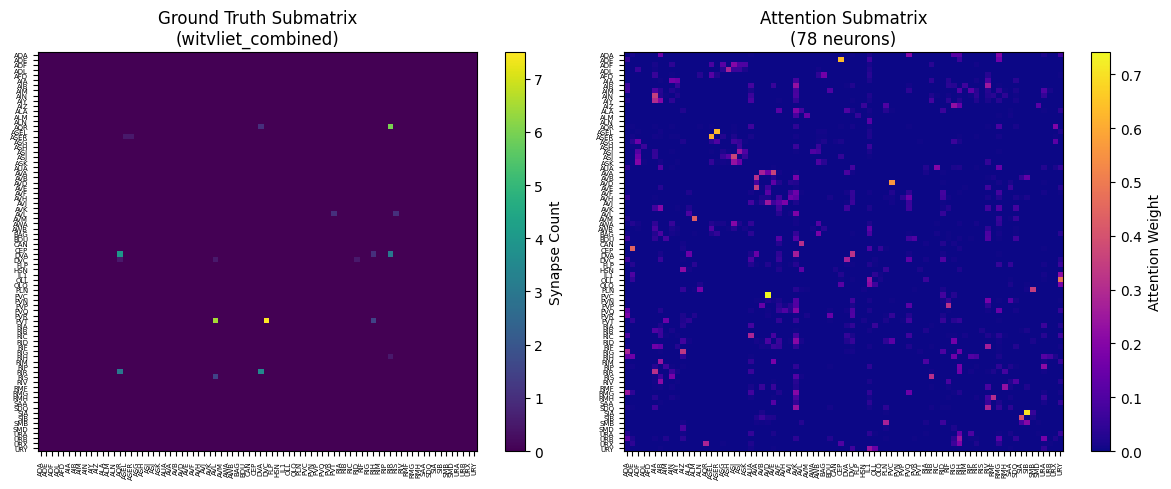


Matrix Statistics: TRANSCRIPTOMICS

Learned Attention Matrix:
  Shape: (130, 130)
  Mean: 0.007692
  Std: 0.044091
  Max: 1.000000
  Sparsity: 0.925

WITVLIET_COMBINED Comparison:
  Overlapping neurons: 78
  Correlation: r = 0.0029
  P-value: 8.23e-01
  Valid data points: 6006
  GT submatrix - Mean: 0.007150, Std: 0.176923, Max: 7.5
  GT submatrix - Sparsity: 0.997


In [42]:
# Comprehensive Matrix Visualization: Full vs Submatrices
comparison_results_transcriptomics = compare_attention_with_ground_truth(
    attention_matrix=attention_weights_transcriptomics,
    attention_neuron_labels=neuron_labels,
    ground_truth_matrices=dict(witvliet_combined=gt_adj_combined),
    ground_truth_neuron_labels=dict(witvliet_combined=neurons_7_8_all),
    phase_name="Transcriptomics",
    label_to_class_mapping=label_to_class,
    exclude_bwm=True
)

# Store results for later use
overlap_neurons_transcriptomics = comparison_results_transcriptomics['comparisons']['witvliet_combined']['overlap_neurons']
gt_submatrix_transcriptomics = comparison_results_transcriptomics['comparisons']['witvliet_combined']['gt_submatrix']
attention_submatrix_transcriptomics = comparison_results_transcriptomics['comparisons']['witvliet_combined']['attention_submatrix']


# ============================================================================
# Phase 2: NEURAL DYNAMICS as Embeddings
# ============================================================================

## Overview
Replace transcriptomic embeddings with neural dynamics time series as the representation to reconstruct. Train the same `SingleHeadSelfAttention` model to learn how neurons attend to each other's temporal activity patterns. Compare results with Phase 1 (transcriptomics).


In [ ]:
# Configuration for neural dynamics phase
CONFIG_DYNAMICS = {
    'seq_len': 256,           # Temporal window length (embedding dimension)
    'stride': 1,               # Sliding window stride
    'train_val_split': 0.2,    # Train/validation split
    'hidden_dim': 512,         # Hidden dimension for Q/K/V
    'batch_size': 8,          # Batch size
    'learning_rate': 1e-3,     # Learning rate
    'use_attention_scores': False, # Use attention scores instead of weights
    'attn_dropout': 0.01,  # Dropout for attention mask beyond diagonal (self) masking
    'consistency_weight': 0.0,  # Weight for batch consistency regularization
    'consistency_type': 'variance',  # 'variance' (default) or 'frobenius'
    'n_layers': 3,           # Number of decoder blocks (1 = shallow, >1 = deep)
    'mlp_expansion': 2,      # MLP hidden layer expansion factor
    'dropout': 0.1,          # Dropout rate for MLP layers
}

print("Phase 2 Configuration (Neural Dynamics):")
for key, value in CONFIG_DYNAMICS.items():
    print(f"  {key}: {value}")


Phase 2 Configuration (Neural Dynamics):
  seq_len: 256
  stride: 1
  train_val_split: 0.2
  hidden_dim: 512
  batch_size: 8
  learning_rate: 0.001
  use_attention_scores: False
  attn_dropout: 0.01
  consistency_weight: 0.0
  consistency_type: variance
  dataset_type: random_projection
  n_layers: 3
  mlp_expansion: 2
  dropout: 0.1


In [40]:
# Initialize model for dynamics phase
model_dynamics = SingleHeadSelfAttention(
    d_model=CONFIG_DYNAMICS['seq_len'], # d_model = seq_len (temporal window is the "embedding")
    n_hidden=CONFIG_DYNAMICS['hidden_dim'],
    use_attention_scores=CONFIG_TRANSCRIPTOMICS['use_attention_scores']
).to(device)

print(f"\nSingleHeadSelfAttention created with {sum(p.numel() for p in model_dynamics.parameters()):,} parameters")
print(f"Model architecture: {model_dynamics}")



SingleHeadSelfAttention created with 262,144 parameters
Model architecture: SingleHeadSelfAttention(
  (W_Q): Linear(in_features=256, out_features=512, bias=False)
  (W_K): Linear(in_features=256, out_features=512, bias=False)
  (W_V): Identity()
)


In [41]:
# # Using a DeepConnectomeTransformer model
# model_dynamics = DeepConnectomeTransformer(
#     d_model=CONFIG_DYNAMICS['seq_len'],
#     n_hidden=CONFIG_DYNAMICS['hidden_dim'],
#     n_layers=CONFIG_DYNAMICS['n_layers'], 
#     mlp_expansion=CONFIG_DYNAMICS['mlp_expansion'],
#     dropout=CONFIG_DYNAMICS['dropout'],
#     use_attention_scores=CONFIG_DYNAMICS['use_attention_scores']
# ).to(device)

# print(f"\nDeepConnectomeTransformer created with {sum(p.numel() for p in model_dynamics.parameters()):,} parameters")
# print(f"Model architecture: {model_dynamics}")


In [42]:
# Load processed neural dynamics data
# NOTE: First run notebooks/load_neural_dynamics.ipynb to process the JSON files
# Choose randomly from os.listdir('data/dynamics/wormwideweb/processed')
random_file = np.random.choice(os.listdir('data/dynamics/wormwideweb/processed')).item()
dynamics_file = Path(f'data/dynamics/wormwideweb/processed/{random_file}')

# Reload with correct structure
with np.load(dynamics_file, allow_pickle=True) as data:
    trace_array = data['trace_array']      # (N_neurons, T) - already filtered to labeled neurons
    neuron_labels = data['neuron_labels'].tolist()  # List of neuron labels
    neuron_classes = data['neuron_classes'].tolist()  # List of neuron classes
    labeled_indices = data['labeled_indices'].tolist()  # Original indices in full array
    metadata = data['metadata'].item()

print(f"Neural dynamics data:")
print(f"  Processed File: {random_file}")
print(f"  Source File: {metadata['source']}")
print(f"  N_neurons (labeled): {metadata['n_neurons']}")
print(f"  N_timepoints: {metadata['n_timepoints']}")
print(f"  Shape: {trace_array.shape}")
print(f"  Neuron labels: {len(neuron_labels)}")
print(f"  Neuron classes: {len(neuron_classes)}")

# Store neuron count
N_neurons_dynamics = trace_array.shape[0]


Neural dynamics data:
  Processed File: atanas_kim_2023-2023-01-23-21_processed.npz
  Source File: atanas_kim_2023-2023-01-23-21.json
  N_neurons (labeled): 101
  N_timepoints: 1600
  Shape: (101, 1600)
  Neuron labels: 101
  Neuron classes: 101


In [43]:
# NeuralDynamicsDataset for Phase 2
class NeuralDynamicsDataset(Dataset):
    """
    Dataset that creates overlapping temporal windows from neural activity time series.
    Each sample is a (N_neurons, seq_len) tensor representing a temporal chunk.
    """
    
    def __init__(self, trace_array, seq_len, stride=1, device='cpu', repeat_factor=1):
        """
        Args:
            trace_array: (N_neurons, T) numpy array of neural activity
            seq_len: length of each temporal window
            stride: stride for sliding window (default=1 for maximum overlap)
            device: torch device to move data to
            repeat_factor: int, number of times to repeat the trace array temporally
                          (e.g., repeat_factor=3 makes dataset 3x larger)
        """
        self.trace_array = trace_array  # (N_neurons, T)
        self.seq_len = seq_len
        self.stride = stride
        self.device = device
        self.repeat_factor = repeat_factor
        
        self.N_neurons, self.T = trace_array.shape
        
        # Repeat trace array temporally if repeat_factor > 1
        if repeat_factor > 1:
            self.trace_array = np.hstack([trace_array] * repeat_factor)
            self.T = self.trace_array.shape[1]
            print(f"  Repeated trace array {repeat_factor} times: {trace_array.shape} -> {self.trace_array.shape}")
        
        # Calculate number of possible windows
        self.n_windows = (self.T - seq_len) // stride + 1
        
        print(f"\nNeuralDynamicsDataset:")
        print(f"  N_neurons: {self.N_neurons}")
        print(f"  Total timepoints: {self.T}")
        print(f"  seq_len: {seq_len}")
        print(f"  stride: {stride}")
        print(f"  repeat_factor: {repeat_factor}")
        print(f"  n_windows: {self.n_windows}")
    
    def __len__(self):
        return self.n_windows
    
    def __getitem__(self, idx):
        """
        Returns:
            tensor of shape (N_neurons, seq_len)
        """
        start_idx = idx * self.stride
        end_idx = start_idx + self.seq_len
        
        # Extract window
        window = self.trace_array[:, start_idx:end_idx]  # (N_neurons, seq_len)
        
        # Convert to tensor and move to device
        window_tensor = torch.tensor(window, dtype=torch.float32, device=self.device)
        
        return window_tensor

In [44]:
# Calculate train/val split
T_total = trace_array.shape[1]
train_end_time = int(T_total * CONFIG_DYNAMICS['train_val_split'])

# Split time series temporally
train_trace = trace_array[:, train_end_time:] 
val_trace = trace_array[:, :train_end_time] # Make validation set the first part

print(f"Data split:")
print(f"  Train: {train_trace.shape}")
print(f"  Val: {val_trace.shape}")

# Create datasets with repetition for larger dataset
train_dataset_dynamics = NeuralDynamicsDataset(
    trace_array=train_trace,
    seq_len=CONFIG_DYNAMICS['seq_len'],
    stride=CONFIG_DYNAMICS['stride'],
    device=device,
    repeat_factor=1  # Make training dataset kx larger
)

val_dataset_dynamics = NeuralDynamicsDataset(
    trace_array=val_trace,
    seq_len=CONFIG_DYNAMICS['seq_len'],
    stride=CONFIG_DYNAMICS['stride'],
    device=device,
    repeat_factor=1  # Keep validation dataset original size
)

Data split:
  Train: (101, 1280)
  Val: (101, 320)

NeuralDynamicsDataset:
  N_neurons: 101
  Total timepoints: 1280
  seq_len: 256
  stride: 1
  repeat_factor: 1
  n_windows: 1025

NeuralDynamicsDataset:
  N_neurons: 101
  Total timepoints: 320
  seq_len: 256
  stride: 1
  repeat_factor: 1
  n_windows: 65


In [45]:
# L = DataLoader(val_dataset_dynamics, batch_size=CONFIG_DYNAMICS['batch_size'], shuffle=False)
# B = next(iter(L))

# plt.plot(B[0, 0, :].cpu().numpy())
# plt.plot(B[1, 0, :].cpu().numpy())
# plt.title("Same neuron, different timepoints")
# plt.show()

# plt.plot(B[0, 0, :].cpu().numpy())
# plt.plot(B[0, 1, :].cpu().numpy())
# plt.title("Same timepoint, different neurons")
# plt.show() 


Training attention model on neural dynamics...

Batch 10: Train Loss = 0.491835, Val Loss = 0.667603, Time = 1.48s
Batch 20: Train Loss = 0.467240, Val Loss = 0.694068, Time = 1.41s
Batch 30: Train Loss = 0.482260, Val Loss = 0.694529, Time = 1.42s
Batch 40: Train Loss = 0.451458, Val Loss = 0.681215, Time = 1.40s
Batch 50: Train Loss = 0.466399, Val Loss = 0.673613, Time = 1.41s
Batch 60: Train Loss = 0.480312, Val Loss = 0.660824, Time = 1.41s
Batch 70: Train Loss = 0.460422, Val Loss = 0.657668, Time = 1.41s
Batch 80: Train Loss = 0.455482, Val Loss = 0.659108, Time = 1.41s
Batch 90: Train Loss = 0.452913, Val Loss = 0.666534, Time = 1.41s
Batch 100: Train Loss = 0.452511, Val Loss = 0.669996, Time = 1.41s
Batch 110: Train Loss = 0.453811, Val Loss = 0.649520, Time = 1.41s
Batch 120: Train Loss = 0.432020, Val Loss = 0.652538, Time = 1.41s


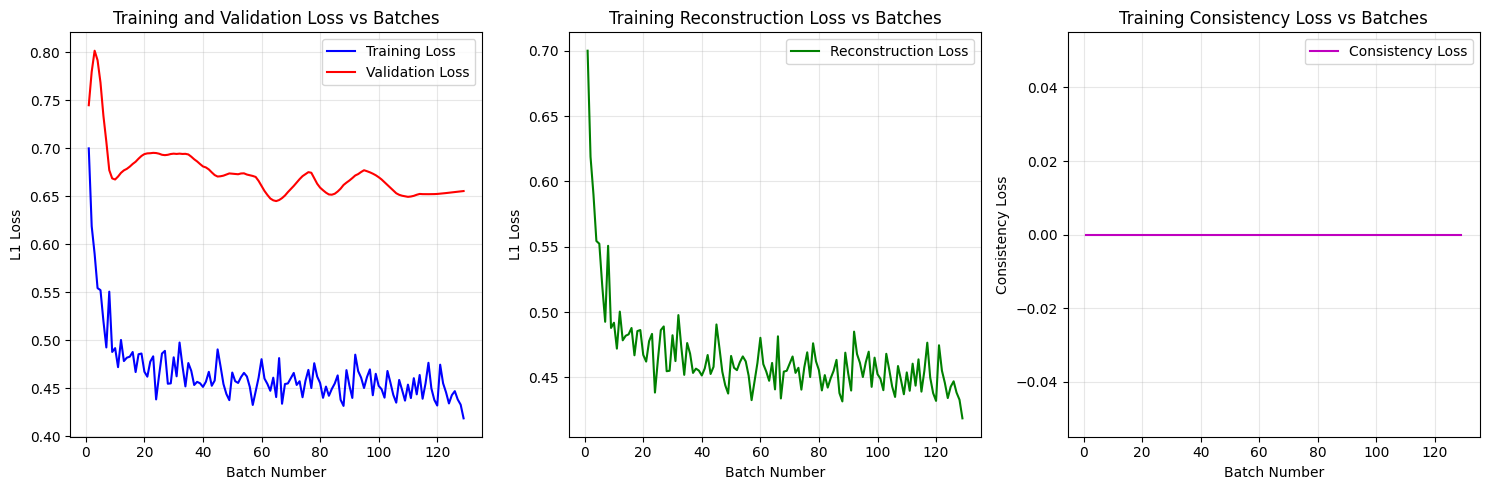

In [46]:
# Train the model using the fixed training function
print("\n" + "="*80)
print("Training attention model on neural dynamics...")
print("="*80 + "\n")

history_dynamics = train_attention_model(
    model=model_dynamics,
    train_dataset=train_dataset_dynamics,
    val_dataset=val_dataset_dynamics,
    config=CONFIG_DYNAMICS,
    device=device
)

# Plot training curves
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(history_dynamics['batch_numbers'], history_dynamics['train_losses'], 'b-', label='Training Loss')
plt.plot(history_dynamics['batch_numbers'], history_dynamics['val_losses'], 'r-', label='Validation Loss')
plt.xlabel('Batch Number')
plt.ylabel('L1 Loss')
plt.title('Training and Validation Loss vs Batches')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(history_dynamics['batch_numbers'], history_dynamics['train_recon_losses'], 'g-', label='Reconstruction Loss')
plt.xlabel('Batch Number')
plt.ylabel('L1 Loss')
plt.title('Training Reconstruction Loss vs Batches')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(history_dynamics['batch_numbers'], history_dynamics['train_consist_losses'], 'm-', label='Consistency Loss')
plt.xlabel('Batch Number')
plt.ylabel('Consistency Loss')
plt.title('Training Consistency Loss vs Batches')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


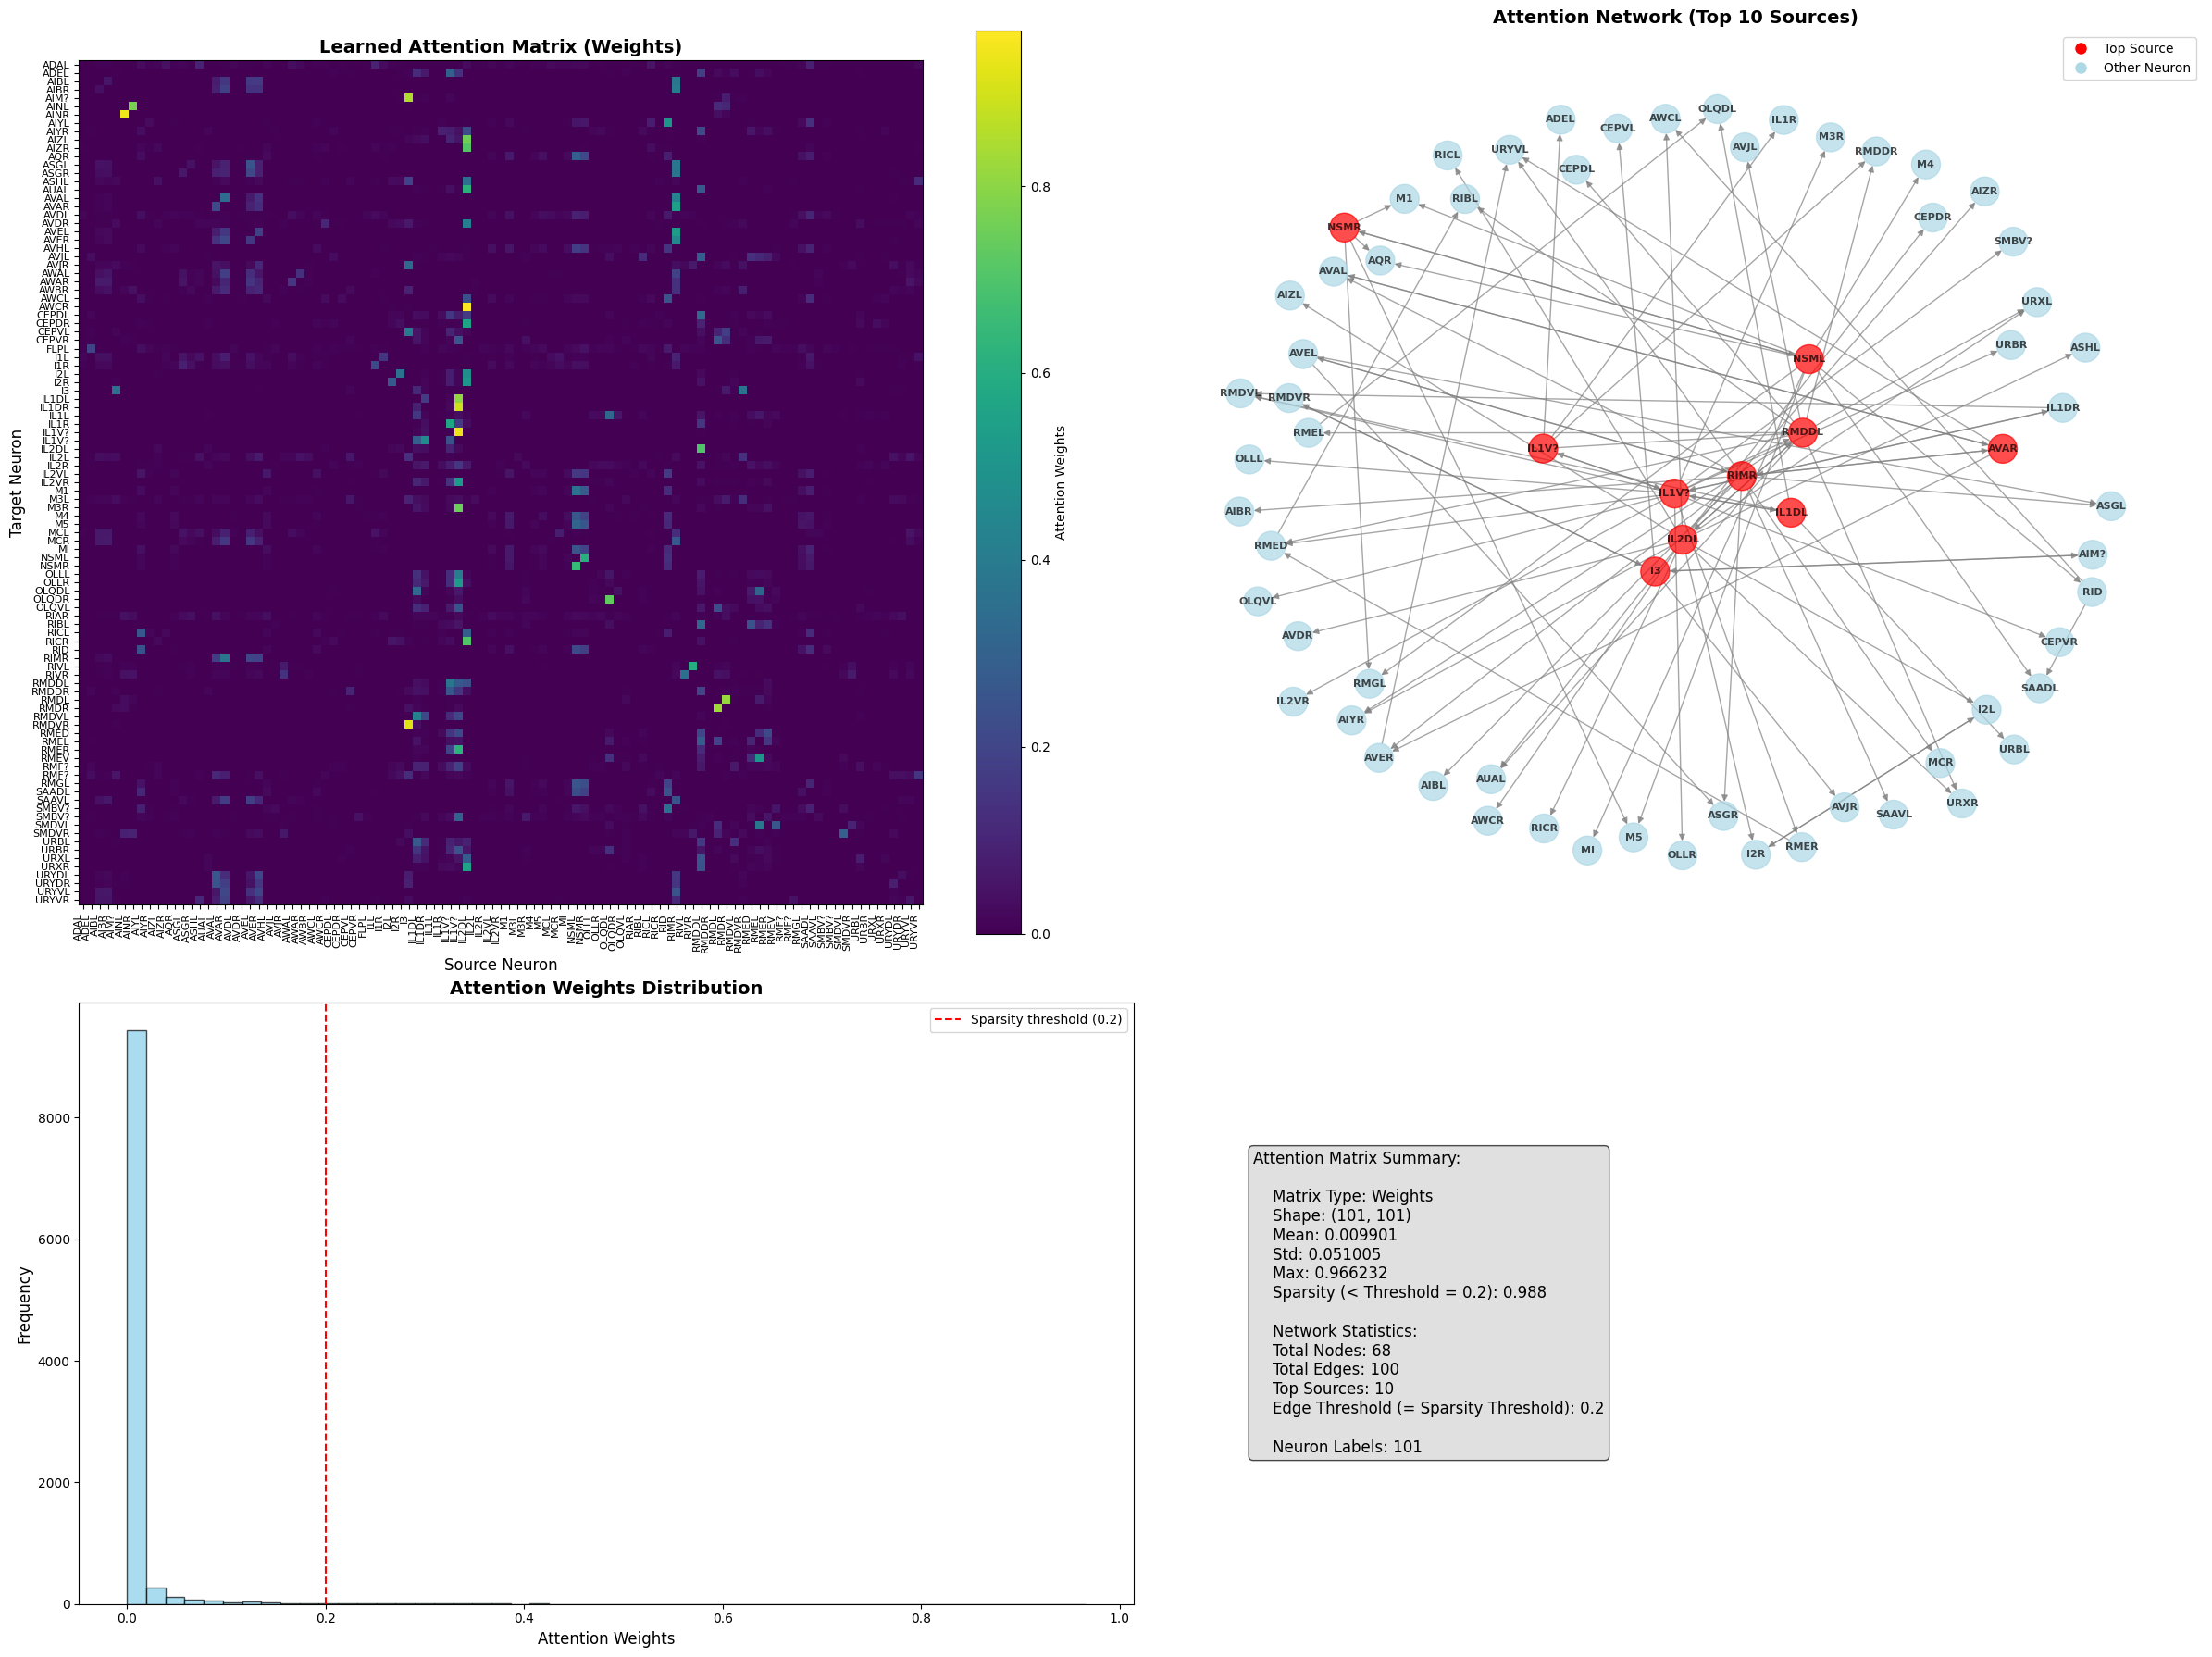


Dynamics Phase Results:
  Attention matrix shape: (101, 101)
  Sparsity: 0.988
  Mean attention weight: 0.009901
  Std attention weight: 0.051005


In [47]:
# Analyze learned attention matrix from neural dynamics phase
results_dynamics = analyze_attention_matrix(
    model=model_dynamics,
    dataset=val_dataset_dynamics,
    neuron_labels=neuron_labels,
    device=device,
    use_attention_scores=CONFIG_DYNAMICS['use_attention_scores'],
    sparsity_thresh=0.2,
    num_graph_sources=10,
)

attention_weights_dynamics = results_dynamics['attention_weights']
attention_scores_dynamics = results_dynamics['attention_scores']

print(f"\nDynamics Phase Results:")
print(f"  Attention matrix shape: {results_dynamics['attention_matrix'].shape}")
print(f"  Sparsity: {results_dynamics['sparsity']:.3f}")
print(f"  Mean attention weight: {results_dynamics['mean']:.6f}")
print(f"  Std attention weight: {results_dynamics['std']:.6f}")



Comparing Ground-Truth Connectome to Learned Attention Matrix (TRANSCRIPTOMICS)

Comparing WITVLIET_COMBINED Connectome to Attention Matrix
Attention neurons: 139
Ground-truth neurons: 260
Overlapping neurons: 79
Overlap percentage: 30.4%
Full matrix shapes: Attention (101, 101), GT (260, 260)
Submatrix shapes: Attention (79, 79), GT (79, 79)
Correlation: r = 0.0429, p = 7.60e-04
Valid data points: 6162/6162


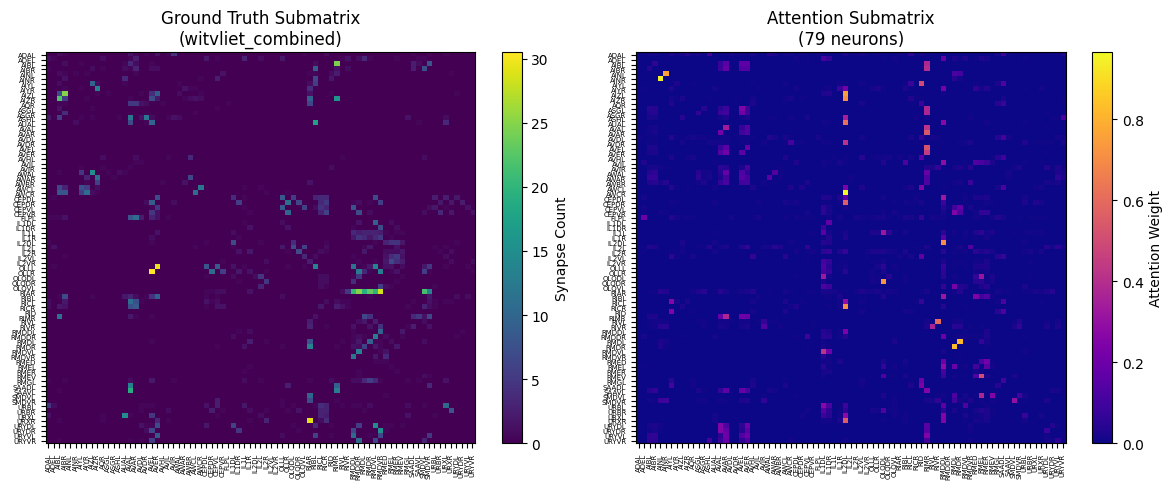


Matrix Statistics: TRANSCRIPTOMICS

Learned Attention Matrix:
  Shape: (101, 101)
  Mean: 0.009901
  Std: 0.051005
  Max: 0.966232
  Sparsity: 0.887

WITVLIET_COMBINED Comparison:
  Overlapping neurons: 79
  Correlation: r = 0.0429
  P-value: 7.60e-04
  Valid data points: 6162
  GT submatrix - Mean: 0.328153, Std: 1.744883, Max: 30.5
  GT submatrix - Sparsity: 0.895


In [48]:
# Comprehensive Matrix Visualization: Full vs Submatrices
comparison_results_dynamics = compare_attention_with_ground_truth(
    attention_matrix=attention_weights_dynamics,
    attention_neuron_labels=neuron_labels,
    ground_truth_matrices=dict(witvliet_combined=gt_adj_combined),
    ground_truth_neuron_labels=dict(witvliet_combined=neurons_7_8_all),
    phase_name="Transcriptomics",
    label_to_class_mapping=label_to_class,
    exclude_bwm=True
)

# Store results for later use
overlap_neurons_dynamics = comparison_results_dynamics['comparisons']['witvliet_combined']['overlap_neurons']
gt_submatrix_dynamics = comparison_results_dynamics['comparisons']['witvliet_combined']['gt_submatrix']
attention_submatrix_dynamics = comparison_results_dynamics['comparisons']['witvliet_combined']['attention_submatrix']


## Functional Connectome Data (Randi et al. 2023)

We now load functional connectome data from Randi et al. (2023) which provides neural signal propagation measurements. This data represents functional connectivity based on calcium imaging experiments where neurons were stimulated and responses were recorded across the network.

**Data Structure:**
- **Sheet 1**: "Figure2a, df_over_f" - Normalized change in fluorescence (df/f) values
- **Sheet 2**: "Figure2a, alpha=(1 - q_val)" - Statistical significance values
- **Format**: 168 neurons × 168 neurons matrix
- **Values**: Can be positive (excitatory), negative (inhibitory), or NaN (not measured)

**Reference:**
> Randi, F., Sharma, A.K., Dvali, S. et al. Neural signal propagation atlas of Caenorhabditis elegans. Nature 623, 406–414 (2023). https://doi.org/10.1038/s41586-023-06683-4


In [49]:
# Load Randi 2023 functional connectome data
print("Loading Randi 2023 functional connectome data...")

# Load both sheets
functional_df_over_f = pd.read_excel(
    'data/connectomics/CElegansFunctionalConnectivity.xlsx',
    sheet_name='Figure2a, df_over_f'
)
functional_alpha = pd.read_excel(
    'data/connectomics/CElegansFunctionalConnectivity.xlsx',
    sheet_name='Figure2a, alpha=(1 - q_val)'
)

# Extract neuron names from first column
neuron_names_functional = functional_df_over_f.iloc[:, 0].tolist()  # Row names
column_names = functional_df_over_f.columns[1:].tolist()  # Column names (skip first column)

print(f"Functional connectome shape: {functional_df_over_f.shape}")
print(f"Number of neurons: {len(neuron_names_functional)}")
print(f"Sample neurons: {neuron_names_functional[:10]}")

def matrix_to_edgelist(matrix_df, neuron_names, type_value, alpha_df=None, alpha_threshold=0.05):
    """
    Convert neuron x neuron matrix to edge-list format as ['pre', 'post', 'type', 'functional'].
    The 'type' column is filled with type_value (e.g. 'df_over_f', 'alpha_1minus_q'), and 
    the 'functional' column contains the value from the matrix (after thresholding/cleaning).
    """
    edges = []

    matrix_values = matrix_df.iloc[:, 1:].values
    if alpha_df is not None:
        alpha_values = alpha_df.iloc[:, 1:].values
    else:
        alpha_values = None

    for i, pre_neuron in enumerate(neuron_names):
        for j, post_neuron in enumerate(neuron_names):
            # Zero out self-connections for consistency with typical convention
            if i == j:
                functional_value = 0.0
            else:
                functional_value = matrix_values[i, j]
                if pd.isna(functional_value):
                    functional_value = 0.0

                # If using alpha filtering, filter by significance
                if alpha_values is not None:
                    alpha_val = alpha_values[i, j]
                    # If not significant or undefined, treat as absent connection
                    if pd.isna(alpha_val) or alpha_val < alpha_threshold:
                        functional_value = 0.0

            edges.append({
                'pre': pre_neuron,
                'post': post_neuron,
                'type': type_value,
                'functional': functional_value
            })
    return pd.DataFrame(edges)

# Create edge-list for df_over_f (raw, no filter)
functional_edgelist_raw = matrix_to_edgelist(
    functional_df_over_f,
    neuron_names_functional,
    type_value='df_over_f',
    alpha_df=None
)

# Create edge-list for df_over_f with alpha significance filtering
functional_edgelist_filtered = matrix_to_edgelist(
    functional_df_over_f,
    neuron_names_functional,
    type_value='df_over_f',
    alpha_df=functional_alpha,
    alpha_threshold=0.05
)

# Create edge-list for alpha (full alpha matrix, for possible significance visualization/stats)
functional_edgelist_alpha = matrix_to_edgelist(
    functional_alpha,
    neuron_names_functional,
    type_value='alpha_1minus_q',
    alpha_df=None
)

print(f"\nRaw functional edge-list shape: {functional_edgelist_raw.shape}")
print(f"Filtered functional edge-list shape: {functional_edgelist_filtered.shape}")
print(f"Alpha edge-list shape: {functional_edgelist_alpha.shape}")
print(f"Non-zero connections (raw): {(functional_edgelist_raw['functional'] != 0).sum()}")
print(f"Non-zero connections (filtered): {(functional_edgelist_filtered['functional'] != 0).sum()}")
print(f"Non-zero alpha entries: {(functional_edgelist_alpha['functional'] != 0).sum()}")

print("\nSample edges (raw, df_over_f):")
print(functional_edgelist_raw[functional_edgelist_raw['functional'] != 0].head())

print("\nSample edges (alpha):")
print(functional_edgelist_alpha[functional_edgelist_alpha['functional'] != 0].head())



Loading Randi 2023 functional connectome data...
Functional connectome shape: (168, 169)
Number of neurons: 168
Sample neurons: ['ADEL', 'ADER', 'ADFL', 'ADLL', 'ADLR', 'AFDL', 'AFDR', 'AQR', 'ASEL', 'ASER']

Raw functional edge-list shape: (28224, 4)
Filtered functional edge-list shape: (28224, 4)
Alpha edge-list shape: (28224, 4)
Non-zero connections (raw): 22353
Non-zero connections (filtered): 11006
Non-zero alpha entries: 12033

Sample edges (raw, df_over_f):
    pre  post       type  functional
1  ADEL  ADER  df_over_f    0.490587
2  ADEL  ADFL  df_over_f    0.117402
3  ADEL  ADLL  df_over_f   -0.011007
6  ADEL  AFDR  df_over_f    0.016940
7  ADEL   AQR  df_over_f    0.102774

Sample edges (alpha):
     pre  post            type  functional
1   ADEL  ADER  alpha_1minus_q    0.947234
2   ADEL  ADFL  alpha_1minus_q    0.098413
7   ADEL   AQR  alpha_1minus_q    0.994309
10  ADEL  ASGL  alpha_1minus_q    0.759721
16  ADEL  ASJL  alpha_1minus_q    0.103646


In [50]:
# Create adjacency matrices for functional connectome
print("\nCreating functional connectome adjacency matrices...")

# Raw (unfiltered)
functional_adj_raw = create_adjacency_matrix(
    functional_edgelist_raw,
    neuron_names_functional,
    weight_col='functional',   # Corrected: use 'functional' column in edge-list
    synapse_type='df_over_f'   # Only take rows where type == 'df_over_f'
)

# Significance-filtered
functional_adj_filtered = create_adjacency_matrix(
    functional_edgelist_filtered,
    neuron_names_functional,
    weight_col='functional',   # Corrected: use 'functional' column
    synapse_type='df_over_f'
)


# # Normalize so each row sums to 1 (add small epsilon for stability)
# eps = 1e-9
# row_sums_raw = functional_adj_raw.sum(axis=1, keepdims=True) + eps
# row_sums_filtered = functional_adj_filtered.sum(axis=1, keepdims=True) + eps
# functional_adj_raw = functional_adj_raw / row_sums_raw
# functional_adj_filtered = functional_adj_filtered / row_sums_filtered

print(f"Functional adjacency matrix (raw) shape: {functional_adj_raw.shape}")
print(f"Functional adjacency matrix (filtered) shape: {functional_adj_filtered.shape}")
print(f"Raw matrix - mean: {functional_adj_raw.mean():.6f}, std: {functional_adj_raw.std():.6f}")
print(f"Filtered matrix - mean: {functional_adj_filtered.mean():.6f}, std: {functional_adj_filtered.std():.6f}")



Creating functional connectome adjacency matrices...
Functional adjacency matrix (raw) shape: (168, 168)
Functional adjacency matrix (filtered) shape: (168, 168)
Raw matrix - mean: 0.028095, std: 0.083492
Filtered matrix - mean: 0.020623, std: 0.076213



Comparing Ground-Truth Connectome to Learned Attention Matrix (DYNAMICS VS FUNCTIONAL CONNECTOME)

Comparing FUNCTIONAL_RAW Connectome to Attention Matrix
Attention neurons: 139
Ground-truth neurons: 236
Overlapping neurons: 91
Overlap percentage: 38.6%
Full matrix shapes: Attention (101, 101), GT (168, 168)
Submatrix shapes: Attention (91, 91), GT (91, 91)
Correlation: r = 0.0430, p = 9.84e-05
Valid data points: 8190/8190


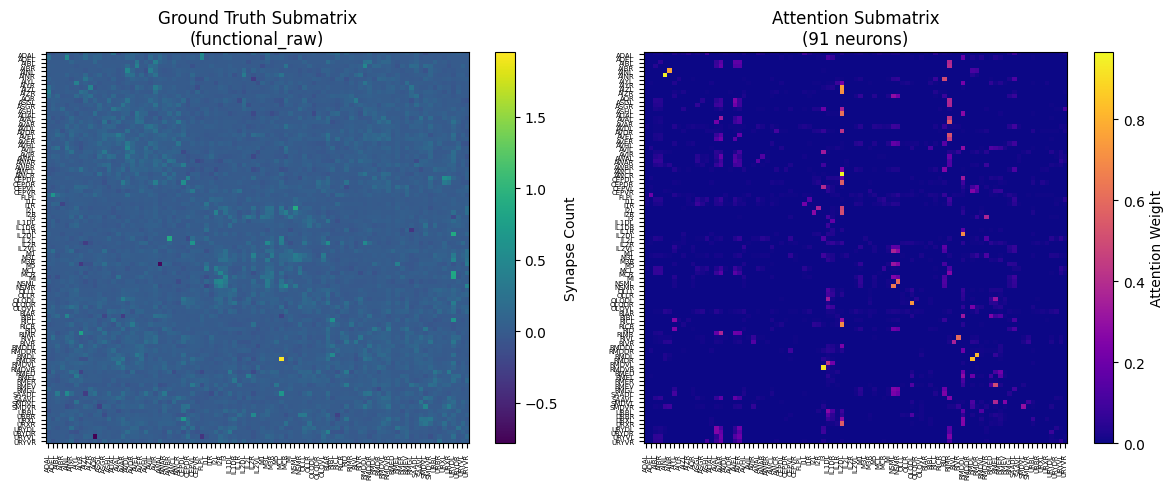


Comparing FUNCTIONAL_FILTERED Connectome to Attention Matrix
Attention neurons: 139
Ground-truth neurons: 236
Overlapping neurons: 91
Overlap percentage: 38.6%
Full matrix shapes: Attention (101, 101), GT (168, 168)
Submatrix shapes: Attention (91, 91), GT (91, 91)
Correlation: r = 0.0490, p = 9.30e-06
Valid data points: 8190/8190


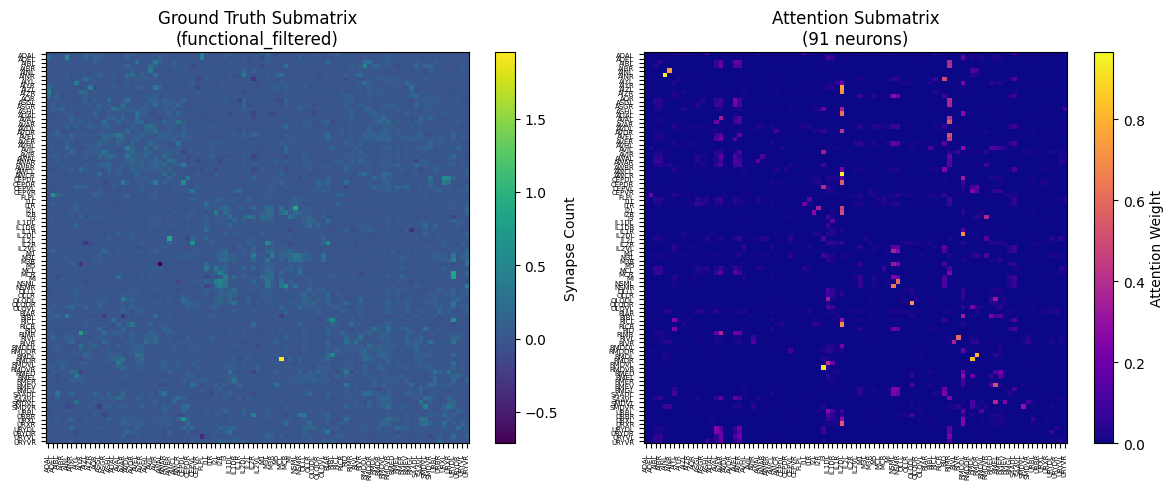


Matrix Statistics: DYNAMICS VS FUNCTIONAL CONNECTOME

Learned Attention Matrix:
  Shape: (101, 101)
  Mean: 0.009901
  Std: 0.051005
  Max: 0.966232
  Sparsity: 0.887

FUNCTIONAL_RAW Comparison:
  Overlapping neurons: 91
  Correlation: r = 0.0430
  P-value: 9.84e-05
  Valid data points: 8190
  GT submatrix - Mean: 0.031886, Std: 0.079488, Max: 2.0
  GT submatrix - Sparsity: 0.124

FUNCTIONAL_FILTERED Comparison:
  Overlapping neurons: 91
  Correlation: r = 0.0490
  P-value: 9.30e-06
  Valid data points: 8190
  GT submatrix - Mean: 0.023921, Std: 0.074166, Max: 2.0
  GT submatrix - Sparsity: 0.549


In [51]:
# Compare dynamics attention matrix with functional connectome
comparison_results_functional = compare_attention_with_ground_truth(
    attention_matrix=attention_weights_dynamics,
    attention_neuron_labels=neuron_labels,
    ground_truth_matrices={
        'functional_raw': functional_adj_raw,
        'functional_filtered': functional_adj_filtered
    },
    ground_truth_neuron_labels={
        'functional_raw': neuron_names_functional,
        'functional_filtered': neuron_names_functional
    },
    phase_name="Dynamics vs Functional Connectome",
    label_to_class_mapping=label_to_class,
    exclude_bwm=True
)
